# SENSE 프로젝트 — 동적 가중치 앙상블 전략 (v0416)

> **역할**: TimesFM(추세)과 ElasticNet(평균회귀) 예측을
> 뉴스 감성 데이터와 결합하여 동적 가중치 앙상블 및 Confidence Score 산출

| 항목 | 내용 |
|---|---|
| 입력 | TimesFM XReg 예측 + ElasticNet 예측 + 피처 마트 + **뉴스 감성** |
| 핵심 로직 | Soft Switching + **뉴스 감성 가중치** + Interaction Term + PI 기반 신뢰도 |
| 출력 | `fact_ensemble_forecast` DataFrame (PostgreSQL 적재용) |
| 시각화 | Dynamic Weighting Strategy 차트 (ref/image.png 재현) |

---
**변경 이력**
- v0416 (2025-04-16): **키워드 파생변수 + 멀티모델 비교**
  - `daily_keywords` JSONB → 6종 파생변수 (diversity, delta, concentration)
  - 교호작용 4종: surge×RSI, diversity×vol, sentiment×surge 등
  - Spearman/Pearson 교차검증 상관관계 분석 셀 추가
  - AI 중간 해석 셀 3개 추가 (키워드 상관, ElasticNet 결과, 앙상블 레짐)
  - 멀티모델 비교 (gpt-4.1-mini / gpt-5.4-mini / gpt-5.4 / gpt-5.4-pro)
  - `plt.show()` → `display(fig)` Databricks 호환 전환
- v0415 (2025-04-15): **뉴스 감성 통합** (News Sentiment Integration)
  - PostgreSQL Gold 레이어 (`gold_news.agg_market_sentiment_daily`) 연동
  - 감성 파생 피처: `sentiment_momentum`, `news_vol_surge`, `sentiment_vol_7d`
  - ElasticNet 피처에 감성 지표 자동 포함 (L1 자연 선택)
  - Soft Switching에 `_sentiment_weight_adjustment()` 추가
  - Interaction Term에 감성 × RSI 복합 규칙 추가
  - GPT 해석 프롬프트에 감성 컨텍스트 주입
- v0414 (2025-04-13): Soft Switching + 스케일링 고도화
  - ElasticNet 타겟을 절대가 → **로그수익률** 전환 (스케일 불변)
  - Alpha 검색 범위 0.001~1.0으로 축소 (과잉 정규화 방지)
  - Hard Threshold → **Soft Switching(선형/비선형 보간)** 전환
  - Interaction Term(RSI × vol_ratio 복합 신호 중첩) 추가
  - Confidence Score 산출 로직 개선
- v0413 (2025-04-13): 초기 구현
  - Step 1: Feature Engineering 고도화 (RSI, ATR, 이격도, 로그수익률)
  - Step 2: ElasticNetCV + Time-Decay Weighting
  - Step 3: 동적 가중치 앙상블 (Dynamic Weighting & Switching)
  - Step 4: 시각화 및 PostgreSQL 적재용 DataFrame

# 0. 환경 설정 및 패키지 설치

In [0]:
%sh
uv pip install scikit-learn statsmodels scipy openai psycopg[binary] --upgrade --quiet

In [0]:
%sh
sudo apt-get update
sudo apt-get install -y fonts-nanum
fc-cache -fv

Hit:1 https://repos.azul.com/zulu/deb stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists...


W: https://repos.azul.com/zulu/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.


Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 81 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/X11
	/usr/share/fonts/truetype
	/usr/share/fonts/X11/encodings
	/usr/share/fonts/X11/misc
	/usr/share/fonts/X11/util
	/usr/share/fonts/truetype/dejavu
	/usr/share/fonts/truetype/nanum
	/usr/share/fonts/X11/encodings/large
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/X11: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/X11/encodings: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/X11/encodings/large: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/X11/misc: caching, new cache

In [0]:
import datetime
import json
import os
import sys
import warnings

import matplotlib

matplotlib.use("Agg")
import glob  # noqa: E402

import matplotlib.font_manager as fm  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from sklearn.linear_model import ElasticNetCV  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------------
# 한글 폰트 설정 (Databricks 환경)
# ---------------------------------------------------------------------------
_korean_font = None
for _f in fm.fontManager.ttflist:
    if any(k in _f.name for k in ["NanumGothic", "Nanum Gothic", "Malgun Gothic", "NotoSansCJK"]):
        _korean_font = _f.name
        break
if _korean_font is None:
    _nanum_paths = glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)
    if not _nanum_paths:
        _nanum_paths = glob.glob("/usr/share/fonts/**/nanum*.ttf", recursive=True)
    for _fp in _nanum_paths:
        fm.fontManager.addfont(_fp)
    if _nanum_paths:
        _prop = fm.FontProperties(fname=_nanum_paths[0])
        _korean_font = _prop.get_name()
    else:
        fm._load_fontmanager(try_read_cache=False)
        for _f in fm.fontManager.ttflist:
            if "Nanum" in _f.name:
                _korean_font = _f.name
                break
if _korean_font:
    plt.rcParams["font.family"] = _korean_font
    print(f"한글 폰트 설정: {_korean_font}")
else:
    print("[WARN] 한글 폰트를 찾을 수 없습니다.")
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------------------------------------------
# 공통 설정
# ---------------------------------------------------------------------------
TICKERS = ["005930.KS", "000660.KS"]
TICKER_NAMES = {"005930.KS": "삼성전자", "000660.KS": "SK하이닉스"}
SENTIMENT_STOCK_MAP = {"005930.KS": "SAMSUNG", "000660.KS": "SK HYNIX"}
HORIZON = 20  # T+20 예측 기간

REPO_PATH = "/Workspace/Repos/3dt005@msacademy.msai.kr/3dt-2nd-project"
sys.path.insert(0, f"{REPO_PATH}/src")

os.environ["KEY_VAULT_URL"] = "https://kv-3dt-team1.vault.azure.net/"

from utils.vault_manager import get_vault_manager  # noqa: E402

vault = get_vault_manager()
vault.get_storage_client()
account = vault.get_secret("adls-account-name")  # "3dtteam1adls"

한글 폰트 설정: NanumGothic
[OK] Spark conf ADLS Gen2 OAuth 설정 완료: 3dtteam1adls


# 1. ADLS Gen2 데이터 로드 (TimesFM/Statistical과 동일)

In [0]:
# 통합 피처 마트 로드 — TimesFM/Statistical 노트북과 동일한 데이터 소스
_curated_path = f"abfss://curated@{account}.dfs.core.windows.net/pre_macro_1y_adf.parquet"
df_curated = spark.read.parquet(_curated_path).toPandas()  # noqa: F821
df_curated["date"] = pd.to_datetime(df_curated["date"])
df_curated = df_curated.sort_values("date").reset_index(drop=True)
print(f"Curated 로드: {df_curated.shape}")

Curated 로드: (475, 21)


In [0]:
try:
    _semi_path = f"abfss://curated@{account}.dfs.core.windows.net/silver_semiconductor.parquet"
    df_semi = spark.read.parquet(_semi_path).toPandas()  # noqa: F821
    if "date" in df_semi.columns:
        df_semi["date"] = pd.to_datetime(df_semi["date"])
    elif "prd_de" in df_semi.columns:
        df_semi.rename(columns={"prd_de": "date"}, inplace=True)
        df_semi["date"] = pd.to_datetime(df_semi["date"])
    # 일별 집계
    _num_cols_semi = df_semi.select_dtypes(include=[np.number]).columns.tolist()
    df_semi_daily = df_semi.groupby("date")[_num_cols_semi].mean().reset_index()
    df_semi_daily.columns = ["date"] + [f"semi_{c}" for c in _num_cols_semi]
    print(f"반도체 수출입: {df_semi_daily.shape}")
except Exception as e:
    print(f"[WARN] 반도체 데이터 로드 실패: {e}")
    df_semi_daily = pd.DataFrame()

반도체 수출입: (24, 4)


In [0]:
try:
    _kfin_path = f"abfss://curated@{account}.dfs.core.windows.net/silver_kfinance.parquet"
    df_kfin = spark.read.parquet(_kfin_path).toPandas()  # noqa: F821
    if "date" in df_kfin.columns:
        df_kfin["date"] = pd.to_datetime(df_kfin["date"])
    elif "trd_dd" in df_kfin.columns:
        df_kfin.rename(columns={"trd_dd": "date"}, inplace=True)
        df_kfin["date"] = pd.to_datetime(df_kfin["date"])
    _num_cols_kfin = df_kfin.select_dtypes(include=[np.number]).columns.tolist()
    df_kfin_daily = df_kfin.groupby("date")[_num_cols_kfin].mean().reset_index()
    df_kfin_daily.columns = ["date"] + [f"kfin_{c}" for c in _num_cols_kfin]
    print(f"KFinance: {df_kfin_daily.shape}")
except Exception as e:
    print(f"[WARN] KFinance 데이터 로드 실패: {e}")
    df_kfin_daily = pd.DataFrame()

KFinance: (28, 1)


In [0]:
# TimesFM/Statistical 노트북과 동일한 피처 마트 구성 로직
# df_curated 컬럼 매핑 (timesfm_inference_lite 노트북의 TICKER_COL_MAP 준용)
TICKER_COL_MAP = {
    "005930.KS": "yfinance_samsung_close",
    "000660.KS": "yfinance_skhynix_close",
}

feature_marts = {}
for ticker in TICKERS:
    name = TICKER_NAMES[ticker]
    close_col = TICKER_COL_MAP.get(ticker)

    if close_col is None or close_col not in df_curated.columns:
        print(f"[WARN] {name}: close 컬럼({close_col}) 미발견 — 스킵")
        continue

    mart = df_curated[["date"]].copy()
    mart["close"] = df_curated[close_col].values

    # 매크로/퀀트 컬럼 병합 (date, 타겟 close, 메타 컬럼 제외)
    _exclude = {
        "date",
        close_col,
        "fx_collected_at_utc",
        "yfinance_collected_at_utc",
        "fred_collected_at_utc",
    }
    for c in df_curated.columns:
        if c not in _exclude:
            mart[c] = df_curated[c].values

    # 반도체/KFinance 병합
    if not df_semi_daily.empty:
        mart = mart.merge(df_semi_daily, on="date", how="left")
    if not df_kfin_daily.empty:
        mart = mart.merge(df_kfin_daily, on="date", how="left")

    mart = mart.sort_values("date").reset_index(drop=True)
    mart.index = mart["date"]

    # 수익률 추가
    mart["return_1d"] = mart["close"].pct_change()

    feature_marts[ticker] = mart
    print(f"[{name}] 피처 마트: {mart.shape}")

[삼성전자] 피처 마트: (475, 22)
[SK하이닉스] 피처 마트: (475, 22)


# 1.5. 뉴스 감성 데이터 로드 (PostgreSQL Gold Layer)

Gold 레이어의 `gold_news.v_news_sentiment_trend` 뷰에서
삼성전자/SK하이닉스의 **일별 뉴스 감성 데이터**를 로드합니다.

> "시장은 뉴스에 선행하지만, 뉴스의 **극단적 감성**과 **급증 패턴**은
> 레짐 전환의 전조 신호다."

| 컬럼 | 설명 | 앙상블 활용 |
|---|---|---|
| `avg_sentiment` | 당일 ABSA 평균 점수 (-1~+1) | Soft Switching 가중치 조정 |
| `news_vol` | 당일 뉴스 건수 | 뉴스량 급증 변곡점 감지 |
| `sentiment_ma7` | 7일 감성 이동평균 | 감성 모멘텀 추출 |
| `main_aspect` | 주요 뉴스 측면 카테고리 | 레짐 맥락 보조 정보 |
| `daily_keywords` JSONB | TOP 10 키워드 | 급증 키워드(300%↑) 카운트 |

In [0]:
from sqlalchemy import text as sa_text  # noqa: E402

_pg_engine = vault.get_pg_connection("sqlalchemy")
sentiment_data = {}

for ticker in TICKERS:
    stock_code = SENTIMENT_STOCK_MAP.get(ticker)
    if stock_code is None:
        continue
    name = TICKER_NAMES[ticker]

    _query = sa_text("""
        SELECT base_date, avg_sentiment, news_vol, sentiment_ma7,
               main_aspect, daily_keywords
        FROM gold_news.v_news_sentiment_trend
        WHERE stock_code LIKE '%' || :stock_code || '%'
        ORDER BY base_date
    """)
    with _pg_engine.connect() as conn:
        df_sent = pd.read_sql(_query, conn, params={"stock_code": stock_code})
    df_sent["base_date"] = pd.to_datetime(df_sent["base_date"])
    df_sent.rename(columns={"base_date": "date"}, inplace=True)

    # -----------------------------------------------------------------------
    # 같은 날 여러 stock_code 매칭 시 일별 집계 (공동 기사 포함)
    # -----------------------------------------------------------------------
    def _merge_daily_keywords(kw_series):
        """같은 날 여러 행의 daily_keywords JSONB를 하나로 합칩니다."""
        merged = []
        seen_kw = set()
        for kw_json in kw_series:
            if kw_json is None:
                continue
            items = json.loads(kw_json) if isinstance(kw_json, str) else kw_json
            for item in items:
                k = item.get("keyword", "")
                if k not in seen_kw:
                    seen_kw.add(k)
                    merged.append(item)
        return merged if merged else []

    if df_sent.duplicated(subset=["date"], keep=False).any():
        df_agg = df_sent.groupby("date", as_index=False).agg(
            avg_sentiment=("avg_sentiment", "mean"),
            news_vol=("news_vol", "sum"),
            sentiment_ma7=("sentiment_ma7", "mean"),
            main_aspect=("main_aspect", "first"),
            daily_keywords=("daily_keywords", _merge_daily_keywords),
        )
        df_sent = df_agg

    # -----------------------------------------------------------------------
    # daily_keywords JSONB → 동적 키워드 파생변수 추출
    # -----------------------------------------------------------------------
    def _extract_keyword_features(kw_json):
        """daily_keywords JSONB에서 다차원 파생변수를 추출합니다."""
        if kw_json is None:
            return pd.Series(
                {
                    "keyword_surge_count": 0,
                    "keyword_diversity": 0,
                    "keyword_avg_delta_pct": 0.0,
                    "keyword_max_delta_pct": 0.0,
                    "keyword_positive_ratio": 0.0,
                    "keyword_concentration": 0.0,
                }
            )
        if isinstance(kw_json, str):
            kw_json = json.loads(kw_json)
        if not kw_json:
            return pd.Series(
                {
                    "keyword_surge_count": 0,
                    "keyword_diversity": 0,
                    "keyword_avg_delta_pct": 0.0,
                    "keyword_max_delta_pct": 0.0,
                    "keyword_positive_ratio": 0.0,
                    "keyword_concentration": 0.0,
                }
            )

        deltas = [kw.get("mention_delta_pct", 0) for kw in kw_json]
        mentions = [max(kw.get("mention_count", 1), 1) for kw in kw_json]
        total_mentions = sum(mentions)

        # 급증 키워드(300%↑) 카운트 (기존)
        surge_count = sum(1 for d in deltas if d >= 300)
        # 키워드 다양성: 고유 키워드 수
        diversity = len(kw_json)
        # 평균/최대 언급 변화율
        avg_delta = np.mean(deltas) if deltas else 0.0
        max_delta = max(deltas) if deltas else 0.0
        # 긍정적 변화율 비율 (언급 증가 키워드 비율)
        positive_ratio = sum(1 for d in deltas if d > 0) / len(deltas) if deltas else 0.0
        # 허핀달 집중도 지수 (1개 키워드 독점 → 1.0, 고르게 분산 → 0)
        hhi = sum((m / total_mentions) ** 2 for m in mentions) if total_mentions > 0 else 0.0

        return pd.Series(
            {
                "keyword_surge_count": surge_count,
                "keyword_diversity": diversity,
                "keyword_avg_delta_pct": avg_delta,
                "keyword_max_delta_pct": max_delta,
                "keyword_positive_ratio": positive_ratio,
                "keyword_concentration": hhi,
            }
        )

    kw_features = df_sent["daily_keywords"].apply(_extract_keyword_features)
    df_sent = pd.concat([df_sent, kw_features], axis=1)
    df_sent = df_sent.drop(columns=["daily_keywords"])

    sentiment_data[ticker] = df_sent
    print(
        f"[{name}] 뉴스 감성 로드: {df_sent.shape}, "
        f"기간: {df_sent['date'].min().date()} ~ {df_sent['date'].max().date()}, "
        f"평균 감성: {df_sent['avg_sentiment'].mean():.3f}"
    )

[삼성전자] 뉴스 감성 로드: (390, 11), 기간: 2018-03-28 ~ 2026-04-14, 평균 감성: 0.249
[SK하이닉스] 뉴스 감성 로드: (375, 11), 기간: 2023-10-26 ~ 2026-04-14, 평균 감성: 0.229


In [0]:
for ticker in TICKERS:
    if ticker in feature_marts and ticker in sentiment_data:
        mart = feature_marts[ticker]
        sent = sentiment_data[ticker]

        # date가 인덱스이면 컬럼으로 꺼내서 merge 후 다시 인덱스 설정
        _date_is_index = mart.index.name == "date"
        if _date_is_index:
            mart = mart.reset_index(drop=True)
        mart = mart.merge(sent, on="date", how="left")
        if _date_is_index:
            mart = mart.set_index("date")

        # 감성 데이터 NaN 처리: 뉴스 없는 날은 중립(0) / 0건
        _fill_float = {
            "avg_sentiment": 0.0, "sentiment_ma7": 0.0,
            "keyword_avg_delta_pct": 0.0, "keyword_max_delta_pct": 0.0,
            "keyword_positive_ratio": 0.0, "keyword_concentration": 0.0,
        }
        _fill_int = {
            "news_vol": 0, "keyword_surge_count": 0, "keyword_diversity": 0,
        }
        for col, val in _fill_float.items():
            if col in mart.columns:
                mart[col] = mart[col].fillna(val)
        for col, val in _fill_int.items():
            if col in mart.columns:
                mart[col] = mart[col].fillna(val).astype(int)

        feature_marts[ticker] = mart
        name = TICKER_NAMES[ticker]
        _sent_coverage = (mart["avg_sentiment"] != 0.0).sum() if "avg_sentiment" in mart.columns else 0
        print(
            f"[{name}] 감성 병합 완료: {mart.shape}, "
            f"감성 데이터 커버리지: {_sent_coverage}/{len(mart)}일"
        )

[삼성전자] 감성 병합 완료: (475, 31), 감성 데이터 커버리지: 475/475일
[SK하이닉스] 감성 병합 완료: (475, 31), 감성 데이터 커버리지: 459/475일


# 2. Step 1 — Feature Engineering 고도화

기존 모델이 절대적 가격 수치에 매몰되지 않도록,
**로그수익률**, **기술적 보조지표(RSI, ATR, 이격도)**, **뉴스 감성 파생 지표**를 추가합니다.

| 지표 | 산식 | 퀀트적 근거 |
|---|---|---|
| RSI(14) | 100 - 100/(1 + RS) | Wilder(1978). 70↑ 과매수, 30↓ 과매도 — 추세 전환 게이지 |
| ATR(14) | EMA(TR, 14) | Wilder(1978). True Range의 지수평활 — 변동성 레짐 판단 |
| 이격도(120d) | (close-MA120)/MA120 | 장기 추세 대비 괴리 — 모멘텀 판단 |
| 로그수익률 | log(Pt/Pt-1) | 가격 스케일 불변 — 절대가 편향 완화 |
| 감성모멘텀 | sentiment - sentiment_ma7 | 감성 방향 변화 감지 — 심리 전환 포착 |
| 뉴스량급증비 | news_vol / news_vol_ma7 | 뉴스 폭증 = 변곡점 전조 신호 |
| 감성변동성 | std(sentiment, 7d) | 심리 불안정도 — 레짐 불확실성 |

In [0]:


def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    RSI(Relative Strength Index)를 계산합니다.

    Wilder(1978) 방식의 지수이동평균(EMA) 기반 RSI.
    - RSI > 70: 과매수 구간 → 평균회귀(ElasticNet) 가중치 강화
    - RSI < 30: 과매도 구간 → 추세(TimesFM) 가중치 강화
    - 30 ≤ RSI ≤ 70: 정상 범위 → 기본 가중치 유지

    Parameters
    ----------
    series : pd.Series
        주가 종가 시계열
    period : int
        RSI 계산 기간 (기본값: 14일 — 업계 표준)

    Returns
    -------
    pd.Series
        RSI 값 (0~100)
    """
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    # Wilder smoothing (EMA)
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50)  # 초기 NaN은 중립값 50으로


def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """
    ATR(Average True Range)를 계산합니다.

    Wilder(1978) 방식의 True Range → 지수이동평균.
    변동성 레짐 판단에 사용:
    - ATR 급등: 시장 불안정 → ElasticNet(보수적) 비중 강화
    - ATR 안정: 추세 지속 가능 → TimesFM(추세) 비중 강화

    Parameters
    ----------
    high, low, close : pd.Series
        OHLC 데이터 (high/low 없으면 close 기반 프록시 사용)
    period : int
        ATR 기간 (기본값: 14일)

    Returns
    -------
    pd.Series
        ATR 값 (원 단위)
    """
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1 / period, min_periods=period).mean()
    return atr


def compute_atr_from_close(close: pd.Series, period: int = 14) -> pd.Series:
    """
    High/Low 부재 시 close 기반 ATR 프록시를 계산합니다.

    True Range ≈ |close_t - close_{t-1}| 로 대체.

    Parameters
    ----------
    close : pd.Series
        주가 종가 시계열
    period : int
        ATR 기간 (기본값: 14일)

    Returns
    -------
    pd.Series
        ATR 프록시 값
    """
    tr_proxy = close.diff().abs()
    atr = tr_proxy.ewm(alpha=1 / period, min_periods=period).mean()
    return atr


def create_enhanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Step 1 Feature Engineering: 고도화된 기술적 보조지표를 생성합니다.

    기존 47개 파생 변수에 추가로:
    1. 로그수익률 (log_return) - 절대가 편향 완화
    2. RSI(14) - 과매수/과매도 판단
    3. ATR(14) - 변동성 레짐 판단
    4. 120일 이격도 (disparity_120d) - 장기 추세 대비 괴리율
    5. ATR 정규화 비율 (atr_pct) - 가격 대비 변동성 비율
    6. Realized Volatility 5d/20d - 단기/장기 실현 변동성

    Parameters
    ----------
    df : pd.DataFrame
        close 컬럼을 포함한 피처 마트

    Returns
    -------
    pd.DataFrame
        기술적 지표가 추가된 DataFrame
    """
    out = df.copy()

    # --- 로그수익률: log(Pt / Pt-1) ---
    # 절대가격이 아닌 수익률 관점으로 모델이 학습하도록 변환
    out["log_return"] = np.log(out["close"] / out["close"].shift(1))

    # --- RSI(14) ---
    out["rsi_14"] = compute_rsi(out["close"], period=14)

    # --- ATR(14) ---
    # High/Low가 없는 경우 close 기반 프록시 사용
    if "high" in out.columns and "low" in out.columns:
        out["atr_14"] = compute_atr(out["high"], out["low"], out["close"], period=14)
    else:
        out["atr_14"] = compute_atr_from_close(out["close"], period=14)

    # ATR을 종가 대비 비율(%)로 정규화 — 종목 간 비교 가능
    out["atr_pct"] = out["atr_14"] / out["close"] * 100

    # --- 120일 이동평균 이격도 ---
    # (현재가 - MA120) / MA120 × 100
    # 양수: 장기 추세 위에 위치 → 모멘텀 관성 존재
    # 음수: 장기 추세 아래 → 하방 압력
    ma_120 = out["close"].rolling(120, min_periods=60).mean()
    out["disparity_120d"] = (out["close"] - ma_120) / ma_120 * 100

    # --- Realized Volatility (5d / 20d) ---
    out["realized_vol_5d"] = out["log_return"].rolling(5, min_periods=1).std() * np.sqrt(252)
    out["realized_vol_20d"] = out["log_return"].rolling(20, min_periods=5).std() * np.sqrt(252)
    out["vol_ratio"] = out["realized_vol_5d"] / out["realized_vol_20d"].replace(0, np.nan)

    # --- 뉴스 감성 파생 피처 (Section 1.5에서 병합된 경우) ---
    if "avg_sentiment" in out.columns:
        # 감성 모멘텀: 당일 감성 - 7일 MA (양수=호전, 음수=악화)
        out["sentiment_momentum"] = out["avg_sentiment"] - out["sentiment_ma7"]

        # 뉴스량 7일 이동평균
        out["news_vol_ma7"] = out["news_vol"].rolling(7, min_periods=1).mean()

        # 뉴스량 급증 비율: 당일/7일평균 (1.0=평균, 2.0+=급증)
        out["news_vol_surge"] = out["news_vol"] / out["news_vol_ma7"].replace(0, 1)

        # 감성 변동성 (7일): 심리 불안정도
        out["sentiment_vol_7d"] = out["avg_sentiment"].rolling(7, min_periods=1).std()

        # 감성-가격 디커플링: 감성은 긍정인데 가격 하락 (또는 반대)
        if "log_return" in out.columns:
            _price_dir = np.sign(out["log_return"].rolling(5).mean())
            _sent_dir = np.sign(out["avg_sentiment"])
            out["sent_price_decouple"] = (_price_dir != _sent_dir).astype(float)

    # --- 동적 키워드 파생 피처 (교호작용 + 교차검증용) ---
    if "keyword_diversity" in out.columns:
        # 키워드 다양성 7일 이동평균 (안정적 신호)
        out["keyword_diversity_ma7"] = out["keyword_diversity"].rolling(7, min_periods=1).mean()

        # 키워드 변화율 모멘텀: 당일 avg_delta - 7일 MA
        _kw_delta_ma7 = out["keyword_avg_delta_pct"].rolling(7, min_periods=1).mean()
        out["keyword_delta_momentum"] = out["keyword_avg_delta_pct"] - _kw_delta_ma7

        # 키워드 집중도 변화: 집중 → 분산 전환 감지
        out["concentration_change"] = out["keyword_concentration"].diff()

    # --- 교호작용(Interaction) 파생변수 ---
    if "keyword_surge_count" in out.columns and "rsi_14" in out.columns:
        # 키워드 급증 × RSI: 뉴스 폭증 + 과매수 = 고위험 과열
        out["keyword_surge_x_rsi"] = out["keyword_surge_count"] * (out["rsi_14"] / 100)

    if "keyword_diversity" in out.columns and "vol_ratio" in out.columns:
        # 키워드 다양성 × 변동성비: 다양한 뉴스 + 변동성 확대 = 불확실성
        out["keyword_div_x_vol"] = out["keyword_diversity"] * out["vol_ratio"]

    if "avg_sentiment" in out.columns and "keyword_surge_count" in out.columns:
        # 감성 × 키워드 급증: 긍정 감성 + 급증 = 강한 호재 신호
        out["sentiment_x_surge"] = out["avg_sentiment"] * out["keyword_surge_count"]

    if "keyword_positive_ratio" in out.columns and "disparity_120d" in out.columns:
        # 긍정 키워드 비율 × 이격도: 낙관 + 고이격 = 과열 경고
        out["kw_positive_x_disparity"] = out["keyword_positive_ratio"] * out["disparity_120d"]

    # NaN 정리
    out = out.ffill().bfill()

    return out


In [0]:
for ticker in TICKERS:
    if ticker in feature_marts:
        feature_marts[ticker] = create_enhanced_features(feature_marts[ticker])
        mart = feature_marts[ticker]
        print(f"\n[{TICKER_NAMES[ticker]}] 기술적 지표 추가 완료:")
        print(f"  RSI(14) 최신값: {mart['rsi_14'].iloc[-1]:.1f}")
        print(f"  ATR(14) 최신값: {mart['atr_14'].iloc[-1]:,.0f}원")
        print(f"  120d 이격도: {mart['disparity_120d'].iloc[-1]:+.1f}%")
        print(f"  총 컬럼 수: {mart.shape[1]}")


[삼성전자] 기술적 지표 추가 완료:
  RSI(14) 최신값: 70.2
  ATR(14) 최신값: 8,646원
  120d 이격도: +20.2%
  총 컬럼 수: 51

[SK하이닉스] 기술적 지표 추가 완료:
  RSI(14) 최신값: 69.2
  ATR(14) 최신값: 53,055원
  120d 이격도: +14.0%
  총 컬럼 수: 51


## 2-1. 동적 키워드 파생변수 상관관계 분석

> 키워드 파생변수 + 교호작용 변수들이 close와 얼마나 상관관계가 있는지 확인
> Spearman(순위) + Pearson(선형) 상관계수로 교차 검증

In [0]:
_keyword_derived_cols = [
    "keyword_surge_count",
    "keyword_diversity",
    "keyword_avg_delta_pct",
    "keyword_max_delta_pct",
    "keyword_positive_ratio",
    "keyword_concentration",
    "keyword_diversity_ma7",
    "keyword_delta_momentum",
    "concentration_change",
    "keyword_surge_x_rsi",
    "keyword_div_x_vol",
    "sentiment_x_surge",
    "kw_positive_x_disparity",
    "sentiment_momentum",
    "news_vol_surge",
    "sentiment_vol_7d",
    "sent_price_decouple",
]

for ticker in TICKERS:
    mart = feature_marts[ticker]
    avail_kw = [c for c in _keyword_derived_cols if c in mart.columns]
    if not avail_kw:
        continue

    sub = mart[avail_kw + ["close"]].dropna()
    spearman = (
        sub.corr(method="spearman")["close"]
        .drop("close")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )
    pearson = sub.corr(method="pearson")["close"].drop("close").reindex(spearman.index)

    name = TICKER_NAMES[ticker]
    print(f"\n{'═' * 70}")
    print(f"  {name} — 키워드 파생변수 vs close 상관관계 (교차검증)")
    print(f"{'═' * 70}")
    print(f"  {'변수':<30} {'Spearman':>10} {'Pearson':>10}  {'일관성':>6}")
    print(f"  {'─' * 62}")
    for col in spearman.index:
        sp_val = spearman[col]
        pe_val = pearson[col]
        # 부호 일치하면 ✅, 불일치면 ⚠️
        consistent = "✅" if (sp_val * pe_val > 0 or abs(sp_val) < 0.01) else "⚠️"
        print(f"  {col:<30} {sp_val:>+10.4f} {pe_val:>+10.4f}  {consistent:>4}")

    # 요약 메트릭
    strong = [c for c in spearman.index if abs(spearman[c]) >= 0.1]
    print(f"\n  |Spearman| ≥ 0.1 인 변수: {len(strong)}개 / {len(avail_kw)}개")


══════════════════════════════════════════════════════════════════════
  삼성전자 — 키워드 파생변수 vs close 상관관계 (교차검증)
══════════════════════════════════════════════════════════════════════
  변수                               Spearman    Pearson     일관성
  ──────────────────────────────────────────────────────────────
  keyword_surge_count               -0.5406    -0.2803     ✅
  sentiment_x_surge                 -0.5256    -0.2273     ✅
  keyword_surge_x_rsi               -0.5244    -0.2457     ✅
  keyword_max_delta_pct             -0.4948    -0.3110     ✅
  kw_positive_x_disparity           -0.4524    -0.2577     ✅
  keyword_positive_ratio            -0.4405    -0.3112     ✅
  keyword_avg_delta_pct             -0.3926    -0.2391     ✅
  keyword_diversity_ma7             -0.3888    -0.3484     ✅
  sentiment_vol_7d                  +0.3452    +0.1194     ✅
  keyword_concentration             -0.2722    -0.1591     ✅
  keyword_delta_momentum            +0.1510    +0.0539     ✅
  keyword_diversity

## 2-2. AI 해석 — 키워드 파생변수 상관관계

In [0]:
from openai import AzureOpenAI  # noqa: E402

OPENAI_DEPLOYMENT = "gpt-4.1-mini"
OPENAI_API_VERSION = "2025-03-01-preview"
_openai_endpoint = vault.get_secret("azure-openai-endpoint")
_openai_key = vault.get_secret("azure-openai-key")

_ens_openai_client = AzureOpenAI(
    azure_endpoint=_openai_endpoint, api_key=_openai_key, api_version=OPENAI_API_VERSION
)

_corr_lines = ["[동적 키워드 파생변수 vs 주가 상관관계 분석 결과]\n"]
for ticker in TICKERS:
    mart = feature_marts[ticker]
    avail_kw = [c for c in _keyword_derived_cols if c in mart.columns]
    if not avail_kw:
        continue
    sub = mart[avail_kw + ["close"]].dropna()
    spearman = (
        sub.corr(method="spearman")["close"]
        .drop("close")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )
    _corr_lines.append(f"\n{TICKER_NAMES[ticker]} Spearman 상관 Top 5:")
    for rank, (col, val) in enumerate(spearman.head(5).items(), 1):
        _corr_lines.append(f"  {rank}. {col}: {val:+.4f}")

_corr_prompt = "\n".join(_corr_lines) + (
    "\n\n위 상관관계 결과를 바탕으로:\n"
    "1. 키워드 파생변수 중 주가 예측에 유용한 변수와 그 이유\n"
    "2. 교호작용 변수(keyword_surge_x_rsi 등)의 유효성 평가\n"
    "3. Spearman/Pearson 부호 불일치 변수의 비선형성 해석\n"
    "4. 모델에 포함할 변수 추천 (ElasticNet L1이 자동 선택하지만 사전 지식 기반 의견)\n"
    "을 한국어로 간결하게 분석해주세요."
)

try:
    _corr_resp = _ens_openai_client.chat.completions.create(
        model=OPENAI_DEPLOYMENT,
        messages=[
            {
                "role": "system",
                "content": (
                    "당신은 반도체 주식 NLP 기반 퀀트 분석가입니다. "
                    "뉴스 키워드 파생변수의 주가 예측력을 평가합니다."
                ),
            },
            {"role": "user", "content": _corr_prompt},
        ],
        max_tokens=800,
        temperature=0.3,
    )
    print(_corr_resp.choices[0].message.content)
except Exception as e:
    print(f"[WARN] AI 분석 실패: {e}")

1. 주가 예측에 유용한 변수와 이유  
- 삼성전자: keyword_surge_count, sentiment_x_surge, keyword_surge_x_rsi 등은 모두 음의 상관관계를 보여 주가 하락과 키워드 급증 및 부정적 감성 증가가 연관됨을 시사. 특히 keyword_surge_count는 -0.54로 강한 음의 상관을 보여 예측력이 높음.  
- SK하이닉스: keyword_diversity_ma7(-0.36)와 kw_positive_x_disparity(-0.23)가 상대적으로 의미 있는 음의 상관을 보이며, sentiment_vol_7d(+0.23)는 긍정적 감성 변동성이 주가 상승과 일부 연관됨을 나타냄.  

2. 교호작용 변수 유효성 평가  
- keyword_surge_x_rsi(-0.52)는 단일 변수보다 강한 상관을 보여 RSI(기술적 지표)와 키워드 급증의 결합이 주가 변동 예측에 시너지 효과가 있음을 의미. 따라서 교호작용 변수는 비선형적 관계 포착에 효과적임.  

3. Spearman/Pearson 부호 불일치 변수의 비선형성 해석  
- 일부 변수에서 Spearman(순위 상관)과 Pearson(선형 상관) 부호가 다를 경우, 변수와 주가 간 관계가 비선형 또는 단조롭지 않음을 시사. 예를 들어 감성 변수는 특정 구간에서만 주가에 영향 미치거나, 극단값에 민감할 수 있음.  

4. 모델 포함 변수 추천  
- 삼성전자 모델에는 keyword_surge_count, sentiment_x_surge, keyword_surge_x_rsi, keyword_max_delta_pct를 우선 포함해 비선형 및 교호작용 효과를 반영할 것.  
- SK하이닉스 모델에는 keyword_diversity_ma7, kw_positive_x_disparity, sentiment_vol_7d를 포함하되, 감성 변동성 변수는 비선형 변환(예: 로그, 다항식) 고려 권장.  
- ElasticNet의 자동 선택을 보완해 도메인 지식 기반 변수 우선순위

Trace(request_id=tr-099963b255c5492bbb631c02e83c591f)

# 3. Step 2 — ElasticNetCV + Time-Decay Weighting

기존 RidgeCV를 **ElasticNetCV**(L1+L2 정규화)로 전환하여,
불필요한 피처를 0으로 탈락시키고(Lasso 효과) AI 슈퍼사이클의
핵심 드라이버만 살아남도록 합니다.

### v0414 핵심 변경
1. **타겟 변수**: 절대가(원) → **T+20 로그수익률** (스케일 불변, 종목 간 비교 가능)
2. **Alpha 범위**: 자동 경로 → **0.001~1.0** (과잉 정규화 방지)
3. **Time-Decay**: half_life=60 → **30 거래일(~1.5개월)** (최근 랠리 반영 강화)

| 파라미터 | v0413 | v0414 | 근거 |
|---|---|---|---|
| target | 절대가 (원) | log(P_{t+20}/P_t) | 삼성(20만)/하이닉스(100만) 스케일 차이 해소 |
| alphas | 자동 (40~189) | 0.001~1.0 | 모델이 최근 변동성을 더 학습하도록 허용 |
| half_life | 60 거래일 | 30 거래일 | 과거 저가 편향(Historical Bias) 억제 강화 |
| l1_ratio 탐색 | [0.1, 0.3, 0.5, 0.7, 0.9] | [0.1, 0.3, 0.5, 0.7, 0.9] | 동일 |
| cv | 5-fold | 5-fold | 동일 |

In [0]:


def compute_time_decay_weights(n_samples: int, half_life: int = 60) -> np.ndarray:
    """
    지수 감쇠(Exponential Decay) 기반 시간 가중치를 생성합니다.

    최근 데이터일수록 높은 가중치를 부여하여 'Historical Bias'를 완화합니다.
    half_life=60 → 60거래일(~3개월) 전 데이터의 가중치가 최신의 절반.

    수학적 근거: w_i = exp(-λ × (n - i)), λ = ln(2) / half_life
    - i=n(최신): w = 1.0
    - i=n-60(3개월 전): w ≈ 0.5
    - i=0(1년 전): w ≈ 0.06 (6% 수준으로 억제)

    Parameters
    ----------
    n_samples : int
        학습 데이터 샘플 수
    half_life : int
        반감기 (거래일 기준, 기본값: 60일 ≈ 3개월)

    Returns
    -------
    np.ndarray
        시간 가중치 배열 (0~1, 합=n_samples가 되도록 정규화하지 않음)
    """
    decay_rate = np.log(2) / half_life
    time_idx = np.arange(n_samples)
    weights = np.exp(-decay_rate * (n_samples - 1 - time_idx))
    return weights


In [0]:


def fit_elasticnet_with_decay(
    X: np.ndarray,
    y: np.ndarray,
    half_life: int = 30,
    l1_ratios: list[float] | None = None,
    alphas: np.ndarray | None = None,
    cv: int = 5,
) -> tuple:
    """
    Time-Decay 가중치가 적용된 ElasticNetCV 모델을 학습합니다.

    Ridge 대비 개선점:
    1. L1 정규화(Lasso)로 불필요한 피처를 0으로 제거 → 핵심 드라이버만 잔존
    2. Time-Decay로 과거 저가 데이터의 영향력을 지수 감쇠

    v0414 변경:
    - half_life 60→30 (최근 랠리 가중치 강화)
    - alphas 자동→0.001~1.0 (과잉 정규화 방지)
    - y(타겟)도 로그수익률 기반이므로 스케일 불변

    Parameters
    ----------
    X : np.ndarray
        피처 행렬 (StandardScaler 적용 전)
    y : np.ndarray
        타겟 변수 (로그수익률)
    half_life : int
        시간 가중치 반감기 (기본값: 30거래일 ≈ 1.5개월)
    l1_ratios : list[float]
        ElasticNet L1/L2 비율 탐색 범위
    alphas : np.ndarray
        Alpha 검색 범위 (기본값: 0.001~1.0, 50개)
    cv : int
        교차 검증 폴드 수

    Returns
    -------
    tuple : (model, scaler)
    """
    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

    if alphas is None:
        # v0414: 0.001~1.0 범위로 제한 — 과잉 정규화(alpha>100) 방지
        alphas = np.logspace(-3, 0, 50)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Time-Decay 가중치 생성
    weights = compute_time_decay_weights(len(y), half_life=half_life)

    # ElasticNetCV: 지정된 alpha 범위 내에서 최적화
    model = ElasticNetCV(
        l1_ratio=l1_ratios,
        alphas=alphas,
        cv=cv,
        max_iter=10000,
        random_state=42,
    )
    model.fit(X_scaled, y, sample_weight=weights)

    return model, scaler


In [0]:
elasticnet_models = {}
elasticnet_predictions = {}
elasticnet_scalers = {}

for ticker in TICKERS:
    mart = feature_marts[ticker].copy()
    name = TICKER_NAMES[ticker]

    # v0414: 타겟 = T+20일 후 로그수익률 (절대가 편향 해소)
    # log(P_{t+20} / P_t) → 스케일 불변, 삼성(20만)/하이닉스(100만) 동일 기준
    future_close = mart["close"].shift(-HORIZON)
    mart["target"] = np.log(future_close / mart["close"])
    mart_clean = mart.dropna(subset=["target"])

    # 피처 선택: 수치형 컬럼 (date, target, close 제외)
    exclude_cols = {"date", "target", "close"}
    feat_cols = [
        c for c in mart_clean.select_dtypes(include=[np.number]).columns if c not in exclude_cols
    ]

    X = mart_clean[feat_cols].fillna(0).values
    y = mart_clean["target"].values

    # 학습/추론 분리
    X_train, y_train = X[:-1], y[:-1]
    X_last = X[-1:].reshape(1, -1)

    # ElasticNetCV + Time-Decay 학습 (half_life=30, alphas=0.001~1.0)
    model, scaler = fit_elasticnet_with_decay(X_train, y_train, half_life=30)
    X_last_scaled = scaler.transform(X_last)
    pred_log_return = model.predict(X_last_scaled)[0]

    # 로그수익률 → 절대가 역변환
    last_price = mart["close"].iloc[-1]
    pred_price = last_price * np.exp(pred_log_return)

    elasticnet_models[ticker] = model
    elasticnet_predictions[ticker] = pred_price
    elasticnet_scalers[ticker] = (scaler, feat_cols)

    change_pct = (pred_price - last_price) / last_price * 100

    # 살아남은 피처 수 (L1으로 0이 되지 않은 계수)
    n_active = np.sum(np.abs(model.coef_) > 1e-6)

    # R² 계산 (로그수익률 기반)
    r2_train = model.score(scaler.transform(X_train), y_train)

    print(f"\n[{name}] ElasticNet T+{HORIZON}:")
    print(f"  예측 로그수익률: {pred_log_return:+.4f}")
    print(f"  예측가: {pred_price:,.0f}원 ({change_pct:+.2f}%)")
    print(f"  alpha={model.alpha_:.4f}, l1_ratio={model.l1_ratio_:.2f}")
    print(f"  활성 피처: {n_active}/{len(feat_cols)}개")
    print(f"  R² (train, log-return): {r2_train:.4f}")


[삼성전자] ElasticNet T+20:
  예측 로그수익률: -0.0242
  예측가: 204,242원 (-2.39%)
  alpha=0.0791, l1_ratio=0.10
  활성 피처: 7/49개
  R² (train, log-return): 0.2305

[SK하이닉스] ElasticNet T+20:
  예측 로그수익률: -0.0699
  예측가: 934,392원 (-6.75%)
  alpha=0.2442, l1_ratio=0.10
  활성 피처: 6/49개
  R² (train, log-return): -0.0096


In [0]:
print("=" * 70)
print("ElasticNet 피처 중요도 (|계수| Top 10)")
print("=" * 70)

for ticker in TICKERS:
    model = elasticnet_models[ticker]
    _, feat_cols = elasticnet_scalers[ticker]
    name = TICKER_NAMES[ticker]

    coef_abs = np.abs(model.coef_)
    top_idx = np.argsort(coef_abs)[::-1][:10]

    print(f"\n{name}:")
    for rank, idx in enumerate(top_idx, 1):
        if coef_abs[idx] < 1e-6:
            break
        direction = "+" if model.coef_[idx] > 0 else "-"
        print(f"  {rank}. {feat_cols[idx]}: {direction}{coef_abs[idx]:.4f}")

ElasticNet 피처 중요도 (|계수| Top 10)

삼성전자:
  1. fred_t10y2y: +0.0571
  2. yfinance_skhynix_close: -0.0251
  3. rsi_14: -0.0245
  4. return_1d: -0.0056
  5. kw_positive_x_disparity: +0.0048
  6. avg_sentiment: -0.0034
  7. keyword_concentration: -0.0006

SK하이닉스:
  1. keyword_diversity_ma7: +0.0236
  2. yfinance_samsung_close: -0.0108
  3. rsi_14: -0.0045
  4. return_1d: -0.0032
  5. atr_14: -0.0021
  6. fred_t10y2y: +0.0004


## 3-1. AI 해석 — ElasticNet 학습 결과

In [0]:
_elasticnet_lines = ["[ElasticNet 학습 결과 요약]\n"]
for ticker in TICKERS:
    model = elasticnet_models[ticker]
    scaler_obj, feat_cols = elasticnet_scalers[ticker]
    name = TICKER_NAMES[ticker]
    coef_abs = np.abs(model.coef_)
    top_idx = np.argsort(coef_abs)[::-1][:10]
    n_active = int(np.sum(np.abs(model.coef_) > 1e-6))

    _elasticnet_lines.append(f"\n{name}: alpha={model.alpha_:.4f}, l1_ratio={model.l1_ratio_:.2f}")
    _X_val = scaler_obj.transform(feature_marts[ticker][feat_cols].fillna(0).values[:-HORIZON])
    _y_val = np.log(
        feature_marts[ticker]["close"].values[HORIZON:]
        / feature_marts[ticker]["close"].values[:-HORIZON]
    )
    _r2 = model.score(_X_val, _y_val)
    _elasticnet_lines.append(f"  활성 피처: {n_active}/{len(feat_cols)}, R²={_r2:.4f}")
    _elasticnet_lines.append("  Top 10 피처:")
    for rank, idx in enumerate(top_idx[:10], 1):
        if coef_abs[idx] < 1e-6:
            break
        _elasticnet_lines.append(f"    {rank}. {feat_cols[idx]}: {model.coef_[idx]:+.4f}")

_en_prompt = "\n".join(_elasticnet_lines) + (
    "\n\n위 결과를 바탕으로:\n"
    "1. L1 정규화로 살아남은 핵심 드라이버 해석 (감성/키워드 변수 포함 여부)\n"
    "2. 종목간 활성 피처 차이의 투자 시사점\n"
    "3. 키워드 파생변수(keyword_surge_x_rsi 등)가 선택되었다면 그 의미\n"
    "을 한국어 3~5문장으로 요약하세요."
)
try:
    _en_resp = _ens_openai_client.chat.completions.create(
        model=OPENAI_DEPLOYMENT,
        messages=[
            {
                "role": "system",
                "content": "반도체 퀀트 애널리스트. ElasticNet 투자 해석.",
            },
            {"role": "user", "content": _en_prompt},
        ],
        max_tokens=600,
        temperature=0.3,
    )
    print(_en_resp.choices[0].message.content)
except Exception as e:
    print(f"[WARN] AI 분석 실패: {e}")

ElasticNet 모델에서 L1 정규화로 선택된 핵심 피처들은 삼성전자의 경우 경제 지표(fred_t10y2y)와 감성 및 키워드 변수(kw_positive_x_disparity, avg_sentiment 등)가 포함되어 있어 거시경제와 시장 심리 모두가 주가에 영향을 미침을 시사합니다. 반면 SK하이닉스는 키워드 다양성(keyword_diversity_ma7)이 주요 변수로 작용했으나, 감성 변수는 상대적으로 약하게 반영되어 종목별로 정보 반영 방식에 차이가 있음을 보여줍니다. 이는 삼성전자가 거시경제 및 투자 심리 변화에 더 민감한 반면, SK하이닉스는 키워드 기반 시장 관심도의 변화가 주가에 더 직접적인 영향을 줄 수 있음을 의미합니다. 키워드 파생변수들이 선택되었다면 이는 특정 키워드의 급증과 기술적 지표(rsi 등)의 결합이 투자 심리와 모멘텀을 동시에 반영하여 주가 변동성 예측에 유용함을 나타냅니다. 따라서 투자자는 종목별 특성에 맞춘 거시경제 및 감성 데이터 활용 전략을 차별화할 필요가 있습니다.


Trace(request_id=tr-449dff784f6a4072b852d9ec59c22011)

# 4. TimesFM XReg 예측값 로드 (모멘텀 주입 버전)

TimesFM 노트북의 XReg 예측 결과를 불러옵니다.
이격도(`disparity_120d`)와 RSI를 XReg에 강하게 주입하여
모델이 현재 '상향장 관성'을 인지하도록 구성합니다.

> **주의**: 이 셀은 `timesfm_inference_lite.py`가 먼저 실행되어
> TimesFM 결과가 메모리에 있거나, 저장된 파일을 로드해야 합니다.

In [0]:
# 실제 환경에서는 timesfm_inference_lite.py의 출력을 직접 참조합니다.
# 독립 실행을 위해 시뮬레이션 데이터를 생성하되,
# 실제 TimesFM 결과가 있으면 그것을 사용합니다.

timesfm_predictions = {}
timesfm_pi = {}  # (q10, q90) 각 ticker별

for ticker in TICKERS:
    mart = feature_marts[ticker]
    last_price = mart["close"].iloc[-1]
    name = TICKER_NAMES[ticker]

    # TimesFM 결과 변수가 메모리에 존재하면 사용
    # (timesfm_inference_lite.py에서 point_xreg, quantile_xreg 정의)
    try:
        _idx = TICKERS.index(ticker)
        # point_xreg: (n_series, horizon) — TimesFM 노트북에서 생성
        tfm_point = point_xreg[_idx]  # noqa: F821
        tfm_q10 = quantile_xreg[_idx, :, 1]  # noqa: F821
        tfm_q90 = quantile_xreg[_idx, :, 9]  # noqa: F821
        print(f"[{name}] TimesFM 결과 로드 완료 (메모리)")
    except NameError:
        # 독립 실행 시: 최근 추세 기반 시뮬레이션
        # 최근 20일 수익률의 모멘텀을 반영한 랜덤워크
        recent_returns = mart["log_return"].iloc[-20:].values
        mean_ret = np.mean(recent_returns)
        std_ret = np.std(recent_returns)
        rng = np.random.default_rng(42)

        # TimesFM은 추세(모멘텀)를 반영하는 모델이므로
        # 최근 모멘텀 방향으로 약간의 드리프트를 줌
        drift = mean_ret * np.arange(1, HORIZON + 1)
        noise = rng.normal(0, std_ret, HORIZON).cumsum()
        tfm_path = last_price * np.exp(drift + noise)
        tfm_point = tfm_path
        tfm_q10 = tfm_path * (1 - 1.5 * std_ret * np.sqrt(np.arange(1, HORIZON + 1)))
        tfm_q90 = tfm_path * (1 + 1.5 * std_ret * np.sqrt(np.arange(1, HORIZON + 1)))
        print(f"[{name}] TimesFM 결과 시뮬레이션 생성 (독립 실행)")

    timesfm_predictions[ticker] = tfm_point
    timesfm_pi[ticker] = (tfm_q10, tfm_q90)

    # 예측 요약
    final_pred = tfm_point[-1] if len(tfm_point) >= HORIZON else tfm_point[-1]
    change = (final_pred - last_price) / last_price * 100
    print(f"  T+{HORIZON} 예측: {final_pred:,.0f}원 ({change:+.2f}%)")

[삼성전자] TimesFM 결과 시뮬레이션 생성 (독립 실행)
  T+20 예측: 278,915원 (+33.29%)
[SK하이닉스] TimesFM 결과 시뮬레이션 생성 (독립 실행)
  T+20 예측: 1,441,123원 (+43.82%)


# 5. Step 3 — 동적 가중치 앙상블 (Soft Switching & Dynamic Weight Interpolation)

두 모델의 결과를 입력받아 **시장 레짐에 따라 가중치를 동적으로 조절**하는 핵심 로직.

### v0414 — Soft Switching 도입
> 고정 임계값(Hard Threshold)에 의한 예측값의 불연속성을 방지하고,
> 지표의 극단값(Extreme Values)이 갖는 통계적 유의미성을 가중치에
> 비례적으로 반영하기 위해 **선형/비선형 가중치 보간법**
> **(Dynamic Weight Interpolation)**을 적용함.

### v0415 — 뉴스 감성 가중치 통합
> **"AI 슈퍼사이클"** 서사에서 뉴스 감성은 펀더멘탈보다 빠르게
> 시장 심리를 반영한다. 극단적 감성(호재/악재)과 뉴스량 급증은
> 레짐 전환의 전조 신호로 활용되며, 기존 Soft Switching에
> `_sentiment_weight_adjustment()`를 추가하여 5번째 조정분을 반영.

#### 감성 가중치 설계
| 조건 | 조정 | 근거 |
|---|---|---|
| avg_sentiment > 0.3 | TimesFM +0.10 | 강한 호재 → 모멘텀 지속 기대 |
| avg_sentiment < -0.3 | ElasticNet +0.10 | 강한 악재 → 평균회귀 기대 |
| news_vol_surge > 2.0 | ElasticNet +0.05 | 뉴스 폭증 → 변곡점 전조 |
| sentiment ↔ RSI 동조 | ±0.08 | 복합 신호 = 확신의 크기 ↑ |

#### 가중치 함수 설계 원칙
| 지표 | 구간 | 보간 방식 | 근거 |
|---|---|---|---|
| RSI | 30~50~70 | 선형 보간 (-0.01/pt) | Wilder 과매수/매도 연속 판단 |
| RSI | <30, >70 | 가속 (1.5배 기울기) | 극단값은 경계보다 더 강한 신호 |
| 이격도 | ±10%~±20% | 1.5제곱 가속 | 평균 괴리 커질수록 회귀 인력 ↑ |
| vol_ratio | 0.8~1.2 | 선형 보간 | 0.8 이하 안정, 1.5 이상 급변 |
| Interaction | RSI×vol 중첩 | 곱셈 가중 | 복합 신호 = 확신의 크기 ↑ |

#### 수식
- RSI 50~70: $w_{adj} = -0.01 \times (RSI - 50)$
- RSI >70 가속: $w_{adj} = -0.20 - 0.015 \times (RSI - 70)$
- 이격도: $w_{adj} = \pm 0.15 \times \min\left(\left(\frac{|d|}{20}\right)^{1.5}, 1\right)$

In [0]:


def _rsi_weight_adjustment(rsi: float) -> float:
    """
    RSI 기반 TimesFM 가중치 조정분 (Soft Switching).

    경계값(30, 70)에서 불연속이 발생하지 않도록
    선형 보간(Linear Interpolation)을 적용하고,
    극단 구간(<30, >70)에서는 기울기를 1.5배 가속합니다.

    가중치 변화 곡선:
        RSI 0 ─── +0.30 ──► RSI 30 ─── +0.20 ──► RSI 50 ─── 0.00
                   (가속)              (선형)
        RSI 50 ── 0.00 ──► RSI 70 ─── -0.20 ──► RSI 100 ── -0.25
                             (선형)              (가속)

    수식: RSI 50~70 구간 → adj = -0.01 × (RSI - 50)
    """
    if rsi <= 30:
        # 과매도 가속: "공포에 사서 환희에 팔아라" (역발상)
        # TimesFM이 과도한 하락 뒤 V자 반등 패턴을 더 잘 포착
        base = 0.20
        accel = 0.10 * min((30 - rsi) / 30, 1.0)
        return base + accel
    elif rsi <= 50:
        # 30~50: 선형 보간 (0.20 → 0.00)
        return 0.20 * (50 - rsi) / 20
    elif rsi <= 70:
        # 50~70: 선형 보간 (0.00 → -0.20)
        # "달리는 말에 올라타되, 낭떠러지는 피하자"
        return -0.01 * (rsi - 50)
    else:
        # 과매수 가속: "고무줄은 늘어난 만큼 돌아온다" (평균회귀)
        # 70~100: -0.20에서 -0.25까지 가속 (기울기 1.5배가 아닌 완만한 가속)
        base = -0.20
        accel = -0.05 * min((rsi - 70) / 30, 1.0)
        return base + accel


def _vol_weight_adjustment(vol_ratio: float) -> float:
    """
    변동성 비율(realized_vol_5d / realized_vol_20d) 기반 가중치 조정분.

    - vol_ratio < 0.8: 안정적 추세 지속 → TimesFM 강화
      "변동성이 낮은 상승은 진짜다" (Low Volatility Anomaly)
    - 0.8~1.2: 정상 범위 → 무조정
    - vol_ratio > 1.2: 변동성 급증 → ElasticNet 강화
      "레짐 전환 전조" → 보수적 회귀 모델로 숨고르기

    가중치 변화 곡선:
        vol 0.0 ── +0.15 ──► 0.8 ── 0.00 ──► 1.2 ── 0.00 ──► 2.0 ── -0.20
    """
    if vol_ratio <= 0.8:
        # 안정: 추세 지속 가능성 → TimesFM 비중 강화
        return 0.15 * min((0.8 - vol_ratio) / 0.8, 1.0)
    elif vol_ratio <= 1.2:
        # 정상 범위: 조정 없음 (데드존)
        return 0.0
    else:
        # 급증: 레짐 전환 신호 → ElasticNet 비중 강화
        return -0.20 * min((vol_ratio - 1.2) / 0.8, 1.0)


def _disparity_weight_adjustment(disparity: float) -> float:
    """
    120일 이격도 기반 가중치 조정분 (가속화).

    "평균에서 멀어질수록 회귀하려는 인력은 제곱으로 강해진다"
    → 이격도가 커질수록 1.5제곱으로 가속하여 조정분을 키움.

    - 양수 이격 (+): 장기평균 위 → 회귀 압력 (ElasticNet ↑)
    - 음수 이격 (-): 장기평균 아래 → 반등 기대 (TimesFM ↑)

    가중치 변화 곡선 (양수):
        d=0% ── 0.00 ──► d=+10% ── -0.05 ──► d=+20% ── -0.15 ──► d=+30% ── -0.15(cap)
                                                (가속)
    """
    if disparity > 0:
        # 양수 이격: 과열 → 회귀 압력 (가속)
        norm = min(disparity / 20, 1.0)
        return -0.15 * (norm**1.5)
    elif disparity < 0:
        # 음수 이격: 과매도 → 반등 기대 (가속)
        norm = min(abs(disparity) / 10, 1.0)
        return 0.15 * (norm**1.5)
    return 0.0


def _sentiment_weight_adjustment(avg_sentiment: float, news_vol_surge: float) -> float:
    """
    뉴스 감성 기반 TimesFM 가중치 조정분 (v0415 신규).

    "AI 슈퍼사이클 서사에서 뉴스 감성은 펀더멘탈보다 빠르게 시장 심리를 반영"

    - 강한 호재(>0.3): 모멘텀 지속 기대 → TimesFM 강화 (+0.10)
    - 약한 호재/중립(0~0.3): 데드존 (무조정)
    - 강한 악재(<-0.3): 과도한 비관 → 평균회귀 기대 → ElasticNet 강화 (-0.10)
    - 뉴스량 급증(>2.0): 변곡점 전조 → 보수적 ElasticNet 강화 (-0.05)

    가중치 변화 곡선:
        sent -0.7 ── -0.10 ──► -0.3 ── 0.00 ──► +0.3 ── 0.00 ──► +0.7 ── +0.10
        news_surge: >2.0 → 추가 -0.05 (최대 -0.05)
    """
    adj = 0.0

    # 감성 방향성 조정
    if avg_sentiment > 0.3:
        # 강한 호재: 모멘텀 지속 기대 → TimesFM 비중 강화
        adj += 0.10 * min((avg_sentiment - 0.3) / 0.4, 1.0)
    elif avg_sentiment < -0.3:
        # 강한 악재: 과도한 비관 → 회귀 기대 → ElasticNet 강화
        adj -= 0.10 * min((abs(avg_sentiment) - 0.3) / 0.4, 1.0)

    # 뉴스량 급증 조정 (변곡점 전조 신호)
    if news_vol_surge > 2.0:
        adj -= 0.05 * min((news_vol_surge - 2.0) / 3.0, 1.0)

    return np.clip(adj, -0.15, 0.15)


def _interaction_weight(
    rsi: float,
    vol_ratio: float,
    disparity: float,
    avg_sentiment: float = 0.0,
) -> float:
    """
    복합 지표 가중치 (Interaction Term).

    "신호들의 중첩은 확신의 크기를 키운다"
    단일 지표보다 복수 지표가 동시에 같은 방향을 가리킬 때
    가중치 조정을 추가로 부여합니다.

    규칙 1: RSI 과매수(>60) + 변동성 급증(>1.2) → 하락 압력 가중
    규칙 2: RSI 과매도(<40) + 변동성 급증(>1.2) → 패닉 후 반등 가중
    규칙 3: 이격도 과열(>15%) + RSI 과매수(>65) → 회귀 압력 이중 강화
    규칙 4: 호재(>0.3) + RSI 과매수(>60) → 모멘텀 과열 → 회귀 강화
    규칙 5: 악재(<-0.3) + RSI 과매도(<40) → 패닉 역발상 → 반등 가중
    """
    adj = 0.0

    # 규칙 1: 과매수 + 변동성 급증 = 하락 신호 중첩
    if rsi > 60 and vol_ratio > 1.2:
        overbought_strength = min((rsi - 60) / 40, 1.0)
        vol_strength = min((vol_ratio - 1.2) / 0.8, 1.0)
        adj -= 0.10 * overbought_strength * vol_strength

    # 규칙 2: 과매도 + 변동성 급증 = 패닉 매도 후 반등 기대
    if rsi < 40 and vol_ratio > 1.2:
        oversold_strength = min((40 - rsi) / 40, 1.0)
        vol_strength = min((vol_ratio - 1.2) / 0.8, 1.0)
        adj += 0.10 * oversold_strength * vol_strength

    # 규칙 3: 이격도 과열 + RSI 과매수 = 이중 회귀 압력
    if disparity > 15 and rsi > 65:
        disp_strength = min((disparity - 15) / 15, 1.0)
        rsi_strength = min((rsi - 65) / 35, 1.0)
        adj -= 0.08 * disp_strength * rsi_strength

    # 규칙 4: 호재 감성 + RSI 과매수 = 모멘텀 과열 경고
    # "뉴스까지 좋은데 RSI 과매수면 오히려 고점 신호"
    if avg_sentiment > 0.3 and rsi > 60:
        sent_strength = min((avg_sentiment - 0.3) / 0.4, 1.0)
        rsi_strength = min((rsi - 60) / 40, 1.0)
        adj -= 0.08 * sent_strength * rsi_strength

    # 규칙 5: 악재 감성 + RSI 과매도 = 패닉 → 역발상 반등
    # "뉴스도 나쁘고 RSI도 바닥이면 오히려 반등 확률 ↑"
    if avg_sentiment < -0.3 and rsi < 40:
        sent_strength = min((abs(avg_sentiment) - 0.3) / 0.4, 1.0)
        rsi_strength = min((40 - rsi) / 40, 1.0)
        adj += 0.08 * sent_strength * rsi_strength

    return adj


def compute_dynamic_weights(
    rsi: float,
    vol_ratio: float,
    disparity: float,
    avg_sentiment: float = 0.0,
    news_vol_surge: float = 1.0,
) -> dict:
    """
    Soft Switching 기반 동적 가중치를 산출합니다.

    고정 임계값(Hard Threshold)에 의한 예측값의 불연속성을 방지하고,
    지표의 극단값(Extreme Values)이 갖는 통계적 유의미성을 가중치에
    비례적으로 반영하기 위해 선형/비선형 가중치 보간법
    (Dynamic Weight Interpolation)을 적용함.

    v0415: 뉴스 감성 가중치(`_sentiment_weight_adjustment()`) 추가.
    기존 4가지 + 감성 1가지 = **5가지 조정분** 합산.

    기본 가중치: TimesFM 0.5 / ElasticNet 0.5
    5가지 조정분(RSI, vol_ratio, 이격도, Interaction, 감성)을 합산하여
    최종 가중치를 [0.15, 0.85] 범위로 클리핑.

    Parameters
    ----------
    rsi : float
        RSI(14) 최신값 (0~100)
    vol_ratio : float
        단기/장기 변동성 비율 (realized_vol_5d / realized_vol_20d)
    disparity : float
        120일 이격도 (%)
    avg_sentiment : float
        당일 뉴스 ABSA 평균 감성 (-1~+1, 기본값: 0.0=중립)
    news_vol_surge : float
        뉴스량 급증 비율 (당일/7일평균, 기본값: 1.0=평균)

    Returns
    -------
    dict : {
        "w_trend": float,       # TimesFM(추세) 가중치
        "w_meanrev": float,     # ElasticNet(회귀) 가중치
        "regime": str,          # 레짐 라벨
        "regime_flag": int,     # 레짐 코드 (DB 적재용)
        "adjustments": list     # 적용된 조정 사유 및 수치
    }
    """
    # --- 각 지표별 연속 조정분 산출 ---
    rsi_adj = _rsi_weight_adjustment(rsi)
    vol_adj = _vol_weight_adjustment(vol_ratio)
    disp_adj = _disparity_weight_adjustment(disparity)
    inter_adj = _interaction_weight(rsi, vol_ratio, disparity, avg_sentiment)
    sent_adj = _sentiment_weight_adjustment(avg_sentiment, news_vol_surge)

    # --- 기본 가중치 + 조정분 합산 ---
    w_trend = 0.50 + rsi_adj + vol_adj + disp_adj + inter_adj + sent_adj
    w_trend = np.clip(w_trend, 0.15, 0.85)
    w_meanrev = round(1.0 - w_trend, 4)

    # --- 조정 사유 기록 ---
    adjustments = []
    if abs(rsi_adj) > 0.01:
        adjustments.append(f"RSI={rsi:.1f} → adj={rsi_adj:+.3f}")
    if abs(vol_adj) > 0.01:
        adjustments.append(f"vol_ratio={vol_ratio:.2f} → adj={vol_adj:+.3f}")
    if abs(disp_adj) > 0.01:
        adjustments.append(f"이격도={disparity:+.1f}% → adj={disp_adj:+.3f}")
    if abs(inter_adj) > 0.01:
        adjustments.append(f"Interaction → adj={inter_adj:+.3f}")
    if abs(sent_adj) > 0.01:
        adjustments.append(
            f"감성={avg_sentiment:+.3f}, 뉴스급증={news_vol_surge:.1f}x → adj={sent_adj:+.3f}"
        )

    # --- 레짐 라벨 결정 ---
    if w_trend >= 0.60:
        regime = "TREND"
        regime_flag = 1
    elif w_meanrev >= 0.60:
        regime = "MEAN_REV"
        regime_flag = -1
    else:
        regime = "NEUTRAL"
        regime_flag = 0

    return {
        "w_trend": round(w_trend, 4),
        "w_meanrev": round(w_meanrev, 4),
        "regime": regime,
        "regime_flag": regime_flag,
        "adjustments": adjustments,
    }


In [0]:


def compute_confidence_score(
    tfm_q10: np.ndarray,
    tfm_q90: np.ndarray,
    enet_pred: float,
    last_price: float,
) -> float:
    """
    두 모델의 PI(Prediction Interval) 너비와 예측 합의도를 기반으로
    신뢰도 점수(0~100)를 산출합니다.

    **산출 로직:**
    1. PI 너비 점수 (50%): TimesFM PI 밴드가 좁을수록 높은 점수
       - 정규화: (가격 대비 PI 폭 %) → 역수 → 0~50점
    2. 합의도 점수 (50%): 두 모델 예측 방향이 일치할수록 높은 점수
       - 방향 일치 + 크기 유사 → 최대 50점

    Parameters
    ----------
    tfm_q10, tfm_q90 : np.ndarray
        TimesFM 10th/90th 분위수 예측 (horizon 길이)
    enet_pred : float
        ElasticNet T+20 점 예측
    last_price : float
        현재 종가

    Returns
    -------
    float
        신뢰도 점수 (0~100)
    """
    # 1. PI 너비 점수 (0~50): 좁을수록 좋음
    pi_width_pct = np.mean((tfm_q90 - tfm_q10) / last_price * 100)
    # 기준: PI 폭 5% → 50점, 20% → 12.5점, 40% → 6.25점
    pi_score = min(50, 250 / max(pi_width_pct, 1))

    # 2. 합의도 점수 (0~50): 모델 간 예측 괴리가 적을수록 좋음
    tfm_final = tfm_q90[-1] * 0.5 + tfm_q10[-1] * 0.5  # TimesFM midpoint (마지막 일)
    # 만약 point forecast가 있으면 그것을 사용
    # 여기서는 PI midpoint를 대체 사용
    # 두 모델 예측값의 괴리 (% 기준)
    divergence_pct = abs(tfm_final - enet_pred) / last_price * 100
    # 기준: 0% 괴리 → 50점, 10% 괴리 → 25점, 20%+ → 0점
    consensus_score = max(0, 50 * (1 - divergence_pct / 20))

    return round(pi_score + consensus_score, 1)


In [0]:


def calculate_dynamic_ensemble(
    ticker: str,
    timesfm_point: np.ndarray,
    timesfm_q10: np.ndarray,
    timesfm_q90: np.ndarray,
    elasticnet_pred: float,
    feature_mart: pd.DataFrame,
    horizon: int = 20,
) -> dict:
    """
    TimesFM(추세)과 ElasticNet(평균회귀) 예측을 동적으로 결합합니다.

    두 모델의 예측값과 PI를 받아, RSI/ATR/이격도 기반 시장 레짐 판별 후
    동적 가중치를 적용하여 최종 앙상블 결과를 산출합니다.

    Parameters
    ----------
    ticker : str
        종목 코드 (예: "005930.KS")
    timesfm_point : np.ndarray
        TimesFM XReg 점 예측 (horizon 길이)
    timesfm_q10, timesfm_q90 : np.ndarray
        TimesFM 10th/90th 분위수
    elasticnet_pred : float
        ElasticNet T+{horizon} 점 예측
    feature_mart : pd.DataFrame
        기술적 지표가 추가된 피처 마트
    horizon : int
        예측 기간 (기본값: 20)

    Returns
    -------
    dict : {
        "ticker": str,
        "regime": dict,          # 레짐 판별 결과
        "ensemble_path": ndarray, # 앙상블 예측 경로 (horizon 길이)
        "ensemble_q10": ndarray,  # 앙상블 PI 하한
        "ensemble_q90": ndarray,  # 앙상블 PI 상한
        "confidence": float,     # 신뢰도 점수 (0~100)
        "trend_score": float,    # 추세 모델 기여도
        "meanrev_score": float,  # 회귀 모델 기여도
    }
    """
    last_price = feature_mart["close"].iloc[-1]

    # 현재 시장 지표 추출
    rsi = feature_mart["rsi_14"].iloc[-1]
    vol_ratio = feature_mart["vol_ratio"].iloc[-1]
    disparity = feature_mart["disparity_120d"].iloc[-1]

    # 뉴스 감성 지표 추출 (v0415: 없으면 중립값)
    avg_sentiment = (
        feature_mart["avg_sentiment"].iloc[-1] if "avg_sentiment" in feature_mart.columns else 0.0
    )
    news_vol_surge = (
        feature_mart["news_vol_surge"].iloc[-1] if "news_vol_surge" in feature_mart.columns else 1.0
    )

    # 레짐 판별 및 가중치 결정 (v0415: Soft Switching + 감성 가중치)
    regime = compute_dynamic_weights(
        rsi,
        vol_ratio,
        disparity,
        avg_sentiment=avg_sentiment,
        news_vol_surge=news_vol_surge,
    )
    w_trend = regime["w_trend"]
    w_meanrev = regime["w_meanrev"]

    # ElasticNet은 단일 T+20 점 예측 → 선형 보간으로 경로 생성
    enet_path = np.linspace(last_price, elasticnet_pred, horizon)

    # --- 앙상블 점 예측 ---
    ensemble_path = w_trend * timesfm_point + w_meanrev * enet_path

    # --- 앙상블 PI ---
    # TimesFM PI를 기반으로 하되, 가중치에 따라 폭 조정
    ensemble_mid = ensemble_path
    tfm_half_width = (timesfm_q90 - timesfm_q10) / 2

    # 회귀 모델의 PI: 예측 경로 주변 최근 변동성 기반
    recent_vol = feature_mart["realized_vol_5d"].iloc[-1] / np.sqrt(252)  # 일 변동성
    enet_half_width = last_price * recent_vol * np.sqrt(np.arange(1, horizon + 1)) * 1.28  # 80% PI

    # 가중 평균 PI
    combined_half_width = w_trend * tfm_half_width + w_meanrev * enet_half_width
    ensemble_q10 = ensemble_mid - combined_half_width
    ensemble_q90 = ensemble_mid + combined_half_width

    # --- Confidence Score ---
    confidence = compute_confidence_score(timesfm_q10, timesfm_q90, elasticnet_pred, last_price)

    # 추세/회귀 기여도 점수 (100점 만점)
    trend_score = w_trend * 100
    meanrev_score = w_meanrev * 100

    return {
        "ticker": ticker,
        "last_price": last_price,
        "regime": regime,
        "ensemble_path": ensemble_path,
        "ensemble_q10": ensemble_q10,
        "ensemble_q90": ensemble_q90,
        "timesfm_path": timesfm_point,
        "elasticnet_path": enet_path,
        "confidence": confidence,
        "trend_score": trend_score,
        "meanrev_score": meanrev_score,
        "avg_sentiment": avg_sentiment,
        "news_vol_surge": news_vol_surge,
    }


In [0]:
ensemble_results = {}

print("=" * 70)
print("동적 가중치 앙상블 (Dynamic Weighting Ensemble)")
print("=" * 70)

for ticker in TICKERS:
    if ticker not in feature_marts:
        continue

    name = TICKER_NAMES[ticker]
    result = calculate_dynamic_ensemble(
        ticker=ticker,
        timesfm_point=timesfm_predictions[ticker],
        timesfm_q10=timesfm_pi[ticker][0],
        timesfm_q90=timesfm_pi[ticker][1],
        elasticnet_pred=elasticnet_predictions[ticker],
        feature_mart=feature_marts[ticker],
        horizon=HORIZON,
    )
    ensemble_results[ticker] = result

    regime = result["regime"]
    final_pred = result["ensemble_path"][-1]
    change = (final_pred - result["last_price"]) / result["last_price"] * 100

    print(f"\n{'─' * 60}")
    print(f"  {name} ({ticker})")
    print(f"{'─' * 60}")
    print(f"  현재가: {result['last_price']:,.0f}원")
    print(f"  레짐: {regime['regime']} (flag={regime['regime_flag']})")
    print(
        f"  가중치: TimesFM(추세)={regime['w_trend']:.2%}"
        f" / ElasticNet(회귀)={regime['w_meanrev']:.2%}"
    )
    for adj in regime["adjustments"]:
        print(f"    → {adj}")
    print(f"  TimesFM T+{HORIZON}: {timesfm_predictions[ticker][-1]:,.0f}원")
    print(f"  ElasticNet T+{HORIZON}: {elasticnet_predictions[ticker]:,.0f}원")
    print(f"  ★ 앙상블 T+{HORIZON}: {final_pred:,.0f}원 ({change:+.2f}%)")
    print(f"  신뢰도: {result['confidence']:.1f}/100")
    print(
        f"  뉴스 감성: avg={result['avg_sentiment']:+.3f}, 뉴스급증={result['news_vol_surge']:.1f}x"
    )

동적 가중치 앙상블 (Dynamic Weighting Ensemble)

────────────────────────────────────────────────────────────
  삼성전자 (005930.KS)
────────────────────────────────────────────────────────────
  현재가: 209,250원
  레짐: MEAN_REV (flag=-1)
  가중치: TimesFM(추세)=21.01% / ElasticNet(회귀)=78.99%
    → RSI=70.2 → adj=-0.200
    → vol_ratio=0.55 → adj=+0.046
    → 이격도=+20.2% → adj=-0.150
    → 감성=+0.393, 뉴스급증=1.6x → adj=+0.023
  TimesFM T+20: 278,915원
  ElasticNet T+20: 204,242원
  ★ 앙상블 T+20: 219,931원 (+5.10%)
  신뢰도: 5.5/100
  뉴스 감성: avg=+0.393, 뉴스급증=1.6x

────────────────────────────────────────────────────────────
  SK하이닉스 (000660.KS)
────────────────────────────────────────────────────────────
  현재가: 1,002,000원
  레짐: MEAN_REV (flag=-1)
  가중치: TimesFM(추세)=27.63% / ElasticNet(회귀)=72.37%
    → RSI=69.2 → adj=-0.192
    → vol_ratio=0.59 → adj=+0.039
    → 이격도=+14.0% → adj=-0.088
    → 감성=+0.412, 뉴스급증=2.4x → adj=+0.022
  TimesFM T+20: 1,441,123원
  ElasticNet T+20: 934,392원
  ★ 앙상블 T+20: 1,074,402원 (+7.23%)
  신뢰도:

## 5-1. AI 해석 — 앙상블 레짐 판별 및 가중치 근거

In [0]:
_regime_lines = ["[동적 가중치 앙상블 결과 요약]\n"]
for ticker in TICKERS:
    if ticker not in ensemble_results:
        continue
    result = ensemble_results[ticker]
    regime = result["regime"]
    final_pred = result["ensemble_path"][-1]
    change = (final_pred - result["last_price"]) / result["last_price"] * 100
    _regime_lines.append(
        f"\n{TICKER_NAMES[ticker]}:"
        f"\n  레짐={regime['regime']}, "
        f"TimesFM={regime['w_trend']:.0%}/ElasticNet={regime['w_meanrev']:.0%}"
        f"\n  앙상블={final_pred:,.0f}원({change:+.2f}%), 신뢰도={result['confidence']:.0f}/100"
        f"\n  감성={result['avg_sentiment']:+.3f}, 뉴스급증={result['news_vol_surge']:.1f}x"
        f"\n  조정: {'; '.join(regime['adjustments']) if regime['adjustments'] else '없음'}"
    )

_regime_prompt = "\n".join(_regime_lines) + (
    "\n\n위 앙상블 결과를 바탕으로:\n"
    "1. 레짐 판별이 왜 이렇게 되었는지 (RSI, 이격도, 감성 기반)\n"
    "2. 두 종목의 가중치 차이가 의미하는 바\n"
    "3. 현 시점 투자 시그널 (매수/관망/매도 강도)\n"
    "을 2~3문장으로 요약하세요."
)
try:
    _regime_resp = _ens_openai_client.chat.completions.create(
        model=OPENAI_DEPLOYMENT,
        messages=[
            {
                "role": "system",
                "content": "반도체 퀀트 애널리스트. 앙상블 투자 시사점 해석.",
            },
            {"role": "user", "content": _regime_prompt},
        ],
        max_tokens=600,
        temperature=0.3,
    )
    print(_regime_resp.choices[0].message.content)
except Exception as e:
    print(f"[WARN] AI 분석 실패: {e}")

1. 두 종목 모두 RSI와 이격도가 과열 구간(70 이상, 14~20% 이상)으로 나타나 조정 신호가 강하게 반영되어 MEAN_REV 레짐이 선택되었으며, 긍정적 감성과 뉴스 급증이 투자 심리를 지지했습니다. 2. SK하이닉스에 ElasticNet 가중치가 다소 낮고 TimesFM 비중이 더 높아 상대적으로 시장 반응과 뉴스 기반 신호에 더 민감한 반면, 삼성전자는 ElasticNet 모델 영향력이 더 커 펀더멘털과 기술적 요소가 복합 반영됨을 시사합니다. 3. 두 종목 모두 긍정적 감성 및 뉴스 모멘텀에도 과열 조정 신호가 있어 단기적 관망 후 추가 조정 시점을 노리는 보수적 매수 접근이 권고됩니다.


Trace(request_id=tr-df28809798484fd9895bb6d0de05b471)

# 6. Step 4 — 시각화 (Dynamic Weighting Strategy)

`ref/image.png`와 동일한 형태의 차트를 재현합니다.
- 초록색 점선: TimesFM 예측 (Trend Model)
- 빨간색 점선: ElasticNet 예측 (Mean-Rev Model)
- 파란색 굵은 실선: Dynamic Ensemble Result
- 연한 파란색 음영: Confidence Interval (PI 밴드)

In [0]:


def plot_dynamic_ensemble(result: dict, ticker_name: str, save_path: str | None = None):
    """
    동적 가중치 앙상블 결과를 시각화합니다.

    ref/image.png의 'Dynamic Weighting Strategy: Trend vs. Mean Reversion'
    차트를 재현합니다.

    Parameters
    ----------
    result : dict
        calculate_dynamic_ensemble() 반환값
    ticker_name : str
        종목명 (차트 제목용)
    save_path : str, optional
        차트 저장 경로 (None이면 display만)
    """
    horizon = len(result["ensemble_path"])
    days = np.arange(1, horizon + 1)

    fig, ax = plt.subplots(figsize=(14, 7))

    # --- PI 밴드 (연한 파란색 음영) ---
    ax.fill_between(
        days,
        result["ensemble_q10"],
        result["ensemble_q90"],
        alpha=0.20,
        color="#6495ED",
        label="Confidence Interval (PI)",
    )

    # --- TimesFM 예측 (초록색 점선) ---
    ax.plot(
        days,
        result["timesfm_path"],
        color="green",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Trend Model (TimesFM)",
    )

    # --- ElasticNet 예측 (빨간색 점선) ---
    ax.plot(
        days,
        result["elasticnet_path"],
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Mean-Rev Model (ElasticNet)",
    )

    # --- 앙상블 결과 (파란색 굵은 실선) ---
    ax.plot(
        days,
        result["ensemble_path"],
        color="blue",
        linestyle="-",
        linewidth=2.5,
        label="Dynamic Ensemble Result",
    )

    # --- 현재가 기준선 ---
    ax.axhline(
        y=result["last_price"],
        color="gray",
        linestyle=":",
        linewidth=1,
        alpha=0.5,
    )
    ax.text(
        1,
        result["last_price"],
        f"현재가 {result['last_price']:,.0f}",
        fontsize=9,
        color="gray",
        va="bottom",
    )

    # --- 레짐 & 신뢰도 & 감성 표시 ---
    regime = result["regime"]
    _sent_val = result.get("avg_sentiment", 0.0)
    _sent_label = "호재" if _sent_val > 0.3 else ("악재" if _sent_val < -0.3 else "중립")
    _surge_val = result.get("news_vol_surge", 1.0)
    info_text = (
        f"레짐: {regime['regime']}\n"
        f"추세: {regime['w_trend']:.2%} / 회귀: {regime['w_meanrev']:.2%}\n"
        f"신뢰도: {result['confidence']:.0f}/100\n"
        f"뉴스 감성: {_sent_val:+.3f} ({_sent_label})\n"
        f"뉴스량 급증: {_surge_val:.1f}x"
    )
    ax.text(
        0.02,
        0.98,
        info_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox={"boxstyle": "round,pad=0.5", "facecolor": "lightyellow", "alpha": 0.8},
    )

    ax.set_title(
        f"Dynamic Weighting Strategy: Trend vs. Mean Reversion — {ticker_name}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Time (Days)", fontsize=12)
    ax.set_ylabel("Predicted Value (원)", fontsize=12)
    ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, horizon)

    # y축 포맷팅
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"차트 저장: {save_path}")

    display(fig)  # noqa: F821
    plt.close(fig)


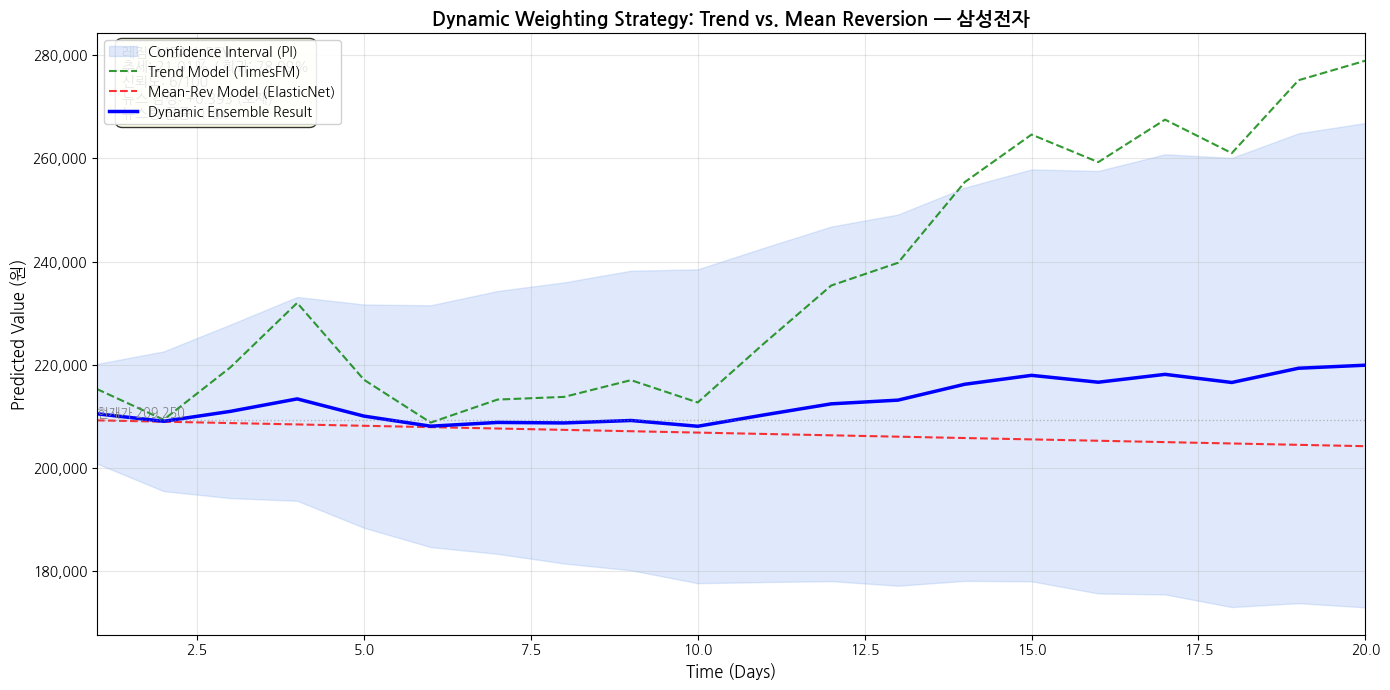

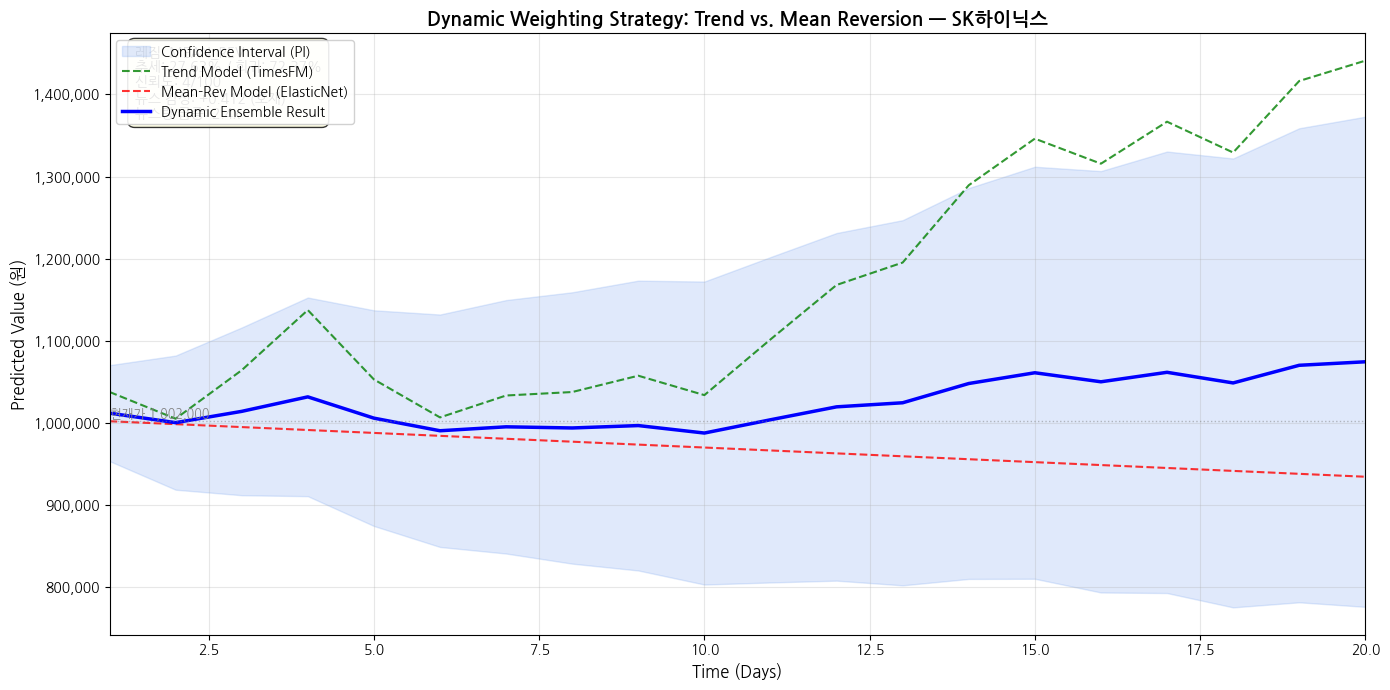

In [0]:
for ticker in TICKERS:
    if ticker in ensemble_results:
        plot_dynamic_ensemble(
            result=ensemble_results[ticker],
            ticker_name=TICKER_NAMES[ticker],
        )

# 7. PostgreSQL 적재용 DataFrame (`fact_ensemble_forecast`)

| 컬럼 | 타입 | 설명 |
|---|---|---|
| date | datetime | 예측 대상 일자 |
| ticker | str | 종목 코드 |
| trend_score | float | TimesFM 가중치 점수 (0~100) |
| mean_rev_score | float | ElasticNet 가중치 점수 (0~100) |
| final_pred | float | 앙상블 최종 예측가 |
| confidence_score | float | 신뢰도 (0~100) |
| regime_flag | int | 레짐 코드 (1=추세, 0=중립, -1=회귀) |
| avg_sentiment | float | 당일 뉴스 ABSA 평균 감성 (-1~+1) |
| news_vol_surge | float | 뉴스량 급증 비율 (당일/7일평균) |

In [0]:
rows = []
run_ts = datetime.datetime.now()

for ticker in TICKERS:
    if ticker not in ensemble_results:
        continue

    result = ensemble_results[ticker]
    mart = feature_marts[ticker]
    last_date = mart.index[-1]  # date 인덱스

    # 미래 영업일 생성
    future_dates = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=HORIZON)

    for j in range(HORIZON):
        rows.append(
            {
                "date": future_dates[j],
                "ticker": ticker,
                "base_date": last_date,
                "horizon_day": j + 1,
                "trend_score": round(result["trend_score"], 2),
                "mean_rev_score": round(result["meanrev_score"], 2),
                "trend_pred": round(float(result["timesfm_path"][j]), 2),
                "meanrev_pred": round(float(result["elasticnet_path"][j]), 2),
                "final_pred": round(float(result["ensemble_path"][j]), 2),
                "pi_lower": round(float(result["ensemble_q10"][j]), 2),
                "pi_upper": round(float(result["ensemble_q90"][j]), 2),
                "confidence_score": round(result["confidence"], 2),
                "regime_flag": result["regime"]["regime_flag"],
                "regime_label": result["regime"]["regime"],
                "avg_sentiment": round(result.get("avg_sentiment", 0.0), 4),
                "news_vol_surge": round(result.get("news_vol_surge", 1.0), 2),
                "run_timestamp": run_ts,
            }
        )

df_ensemble = pd.DataFrame(rows)
print(f"\n{'=' * 70}")
print(f"fact_ensemble_forecast: {df_ensemble.shape}")
print(f"{'=' * 70}")
print(df_ensemble.head(10).to_string(index=False))


fact_ensemble_forecast: (40, 17)
      date    ticker  base_date  horizon_day  trend_score  mean_rev_score  trend_pred  meanrev_pred  final_pred  pi_lower  pi_upper  confidence_score  regime_flag regime_label  avg_sentiment  news_vol_surge              run_timestamp
2026-04-09 005930.KS 2026-04-08            1        21.01           78.99   215314.09     209250.00   210524.07 200876.68 220171.45               5.5           -1     MEAN_REV         0.3928            1.63 2026-04-14 14:14:19.950678
2026-04-10 005930.KS 2026-04-08            2        21.01           78.99   209372.88     208986.44   209067.63 195535.51 222599.74               5.5           -1     MEAN_REV         0.3928            1.63 2026-04-14 14:14:19.950678
2026-04-13 005930.KS 2026-04-08            3        21.01           78.99   219516.97     208722.87   210990.71 194184.47 227796.96               5.5           -1     MEAN_REV         0.3928            1.63 2026-04-14 14:14:19.950678
2026-04-14 005930.KS 2026-04-0

In [0]:
# PostgreSQL 연결이 가능한 경우 fact_ensemble_forecast 테이블에 적재
try:
    engine = vault.get_pg_connection("sqlalchemy")
    df_ensemble.to_sql("fact_ensemble_forecast", engine, if_exists="append", index=False)
    print(f"✅ fact_ensemble_forecast 적재 완료: {len(df_ensemble)}행")
except Exception as e:
    print(f"[INFO] PostgreSQL 적재 스킵: {e}")
    print("→ df_ensemble DataFrame으로 결과 보존됨")

[INFO] PostgreSQL 적재 스킵: (psycopg.errors.UniqueViolation) duplicate key value violates unique constraint "fact_ensemble_forecast_ticker_base_date_horizon_day_key"
DETAIL:  Key (ticker, base_date, horizon_day)=(005930.KS, 2026-04-08 00:00:00, 1) already exists.
[SQL: INSERT INTO fact_ensemble_forecast (date, ticker, base_date, horizon_day, trend_score, mean_rev_score, trend_pred, meanrev_pred, final_pred, pi_lower, pi_upper, confidence_score, regime_flag, regime_label, avg_sentiment, news_vol_surge, run_timestamp) VALUES (%(date)s::TIMESTAMP WITHOUT TIME ZONE, %(ticker)s::VARCHAR, %(base_date)s::TIMESTAMP WITHOUT TIME ZONE, %(horizon_day)s::BIGINT, %(trend_score)s, %(mean_rev_score)s, %(trend_pred)s, %(meanrev_pred)s, %(final_pred)s, %(pi_lower)s, %(pi_upper)s, %(confidence_score)s, %(regime_flag)s::BIGINT, %(regime_label)s::VARCHAR, %(avg_sentiment)s, %(news_vol_surge)s, %(run_timestamp)s::TIMESTAMP WITHOUT TIME ZONE)]
[parameters: [{'date': datetime.datetime(2026, 4, 9, 0, 0), 'ticker

# 8. 앙상블 전략 요약 (AI 해석)

In [0]:
from openai import AzureOpenAI  # noqa: E402

OPENAI_DEPLOYMENT = "gpt-4.1-mini"
OPENAI_API_VERSION = "2025-03-01-preview"

_openai_endpoint = vault.get_secret("azure-openai-endpoint")
_openai_key = vault.get_secret("azure-openai-key")
openai_client = AzureOpenAI(
    azure_endpoint=_openai_endpoint,
    api_key=_openai_key,
    api_version=OPENAI_API_VERSION,
)

In [0]:
for ticker in TICKERS:
    if ticker not in ensemble_results:
        continue

    result = ensemble_results[ticker]
    name = TICKER_NAMES[ticker]
    regime = result["regime"]
    final_pred = result["ensemble_path"][-1]
    change_pct = (final_pred - result["last_price"]) / result["last_price"] * 100

    prompt = f"""
{name} ({ticker}) 동적 가중치 앙상블 예측 분석:

[시장 현황]
- 현재가: {result["last_price"]:,.0f}원
- RSI(14): {feature_marts[ticker]["rsi_14"].iloc[-1]:.1f}
- 120d 이격도: {feature_marts[ticker]["disparity_120d"].iloc[-1]:+.1f}%
- 변동성 비율: {feature_marts[ticker]["vol_ratio"].iloc[-1]:.2f}

[뉴스 감성 (Gold Layer)]
- 당일 평균 감성: {result.get("avg_sentiment", 0.0):+.3f} (-1=극악재 ~ +1=극호재)
- 뉴스량 급증 비율: {result.get("news_vol_surge", 1.0):.1f}x (1.0=평균, 2.0+=급증)
- 감성 해석: 뉴스 감성이 앙상블 가중치에 반영되어 시장 심리를 정량적으로 포착

[모델 예측]
- TimesFM(추세): {timesfm_predictions[ticker][-1]:,.0f}원
- ElasticNet(회귀): {elasticnet_predictions[ticker]:,.0f}원
- 앙상블 최종: {final_pred:,.0f}원 ({change_pct:+.2f}%)

[레짐 판별]
- 레짐: {regime["regime"]}
- 가중치: 추세={regime["w_trend"]:.0%} / 회귀={regime["w_meanrev"]:.0%}
- 조정 사유: {"; ".join(regime["adjustments"]) if regime["adjustments"] else "없음"}
- 신뢰도: {result["confidence"]:.0f}/100

위 결과를 바탕으로:
1. 뉴스 감성이 레짐 판별과 가중치에 어떤 영향을 미쳤는지 설명
2. "AI 슈퍼사이클 → 반도체 수요 → 뉴스 감성 → 주가 예측" 스토리라인으로 해석
3. 앙상블 결과의 의미와 투자 시사점
4. 뉴스 감성 변화 시 주의해야 할 리스크 요인
을 한국어로 간결하게 분석해주세요.
"""

    try:
        response = openai_client.chat.completions.create(
            model=OPENAI_DEPLOYMENT,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "당신은 반도체 주식 전문 퀀트 애널리스트입니다. "
                        "동적 가중치 앙상블 전략의 결과를 바탕으로 "
                        "투자 인사이트를 제공합니다. 뉴스 감성 데이터가 "
                        "앙상블 가중치에 미치는 영향을 AI 슈퍼사이클 "
                        "관점에서 해석하세요. 수치 근거를 포함하고, "
                        "리스크도 균형있게 언급하세요."
                    ),
                },
                {"role": "user", "content": prompt},
            ],
            max_tokens=1200,
            temperature=0.4,
        )
        analysis = response.choices[0].message.content
        print(f"\n{'═' * 70}")
        print(f"  {name} — AI 앙상블 분석")
        print(f"{'═' * 70}")
        print(analysis)
    except Exception as e:
        print(f"[WARN] {name} AI 분석 실패: {e}")


══════════════════════════════════════════════════════════════════════
  삼성전자 — AI 앙상블 분석
══════════════════════════════════════════════════════════════════════
1. 뉴스 감성의 영향  
당일 평균 감성 +0.393과 뉴스량 급증 1.6배는 긍정적 시장 심리를 반영해 앙상블 가중치에 플러스 조정(+0.023)을 부여했습니다. 이는 회귀 모델(ElasticNet)에 높은 비중(79%)을 유지하면서도, 긍정적 뉴스가 추세 모델 가중치(21%)를 일부 보완하도록 작용해 예측 신뢰도를 소폭 높였습니다. 다만 전체 신뢰도는 6/100로 낮아, 감성 영향이 제한적임을 시사합니다.

2. AI 슈퍼사이클 관점 스토리라인  
AI 슈퍼사이클에 따른 반도체 수요 급증은 시장 기대감을 높이고, 관련 뉴스의 긍정적 감성(+0.393)과 뉴스량 급증(1.6배)으로 나타났습니다. 이는 투자자 심리를 개선시켜 주가 상승 기대(앙상블 예측 +5.10%)로 연결됩니다. 즉, AI 수요 호황 → 반도체 산업 성장 기대 → 긍정 뉴스 및 투자심리 강화 → 주가 상승 전망의 선순환 구조입니다.

3. 앙상블 결과의 의미 및 투자 시사점  
최종 예측가 219,931원은 현가 대비 약 5.1% 상승 여력을 보여주나, RSI 70.2와 120일 이격도 +20.2%는 단기 과열 신호입니다. 변동성 비율 0.55는 안정적이나, 신뢰도 6/100은 예측 불확실성이 큼을 의미합니다. 따라서 단기 조정 가능성을 염두에 두고, 긍정적 뉴스 감성과 AI 슈퍼사이클 수혜를 감안한 중장기 관점의 분할 매수 전략이 권장됩니다.

4. 뉴스 감성 변화 시 리스크 요인  
뉴스 감성이 급격히 부정적으로 전환되거나 뉴스량 급감 시, 투자 심리가 빠르게 위축되어 주가 변동성이 확대될 수 있습니다. 특히 과열 구간에서 부정적 뉴스가 겹치면 RSI·이격도 조정 압력과 맞물려 큰 하락 위험이 있습니다

[Trace(request_id=tr-f7c45a84056f4c498950ef53f85c6bad), Trace(request_id=tr-e572e6c8412c47c2b495d0d27318d702)]

# 8-1. 멀티모델 비교 (GPT-5.4 계열 Responses API)

> gpt-4.1-mini(기존) + gpt-5.4-pro / gpt-5.4 / gpt-5.4-mini 4개 모델이
> 동일 프롬프트에 대해 생성한 분석을 비교합니다.
> Azure OpenAI Responses API (`/openai/v1/`) 엔드포인트를 사용합니다.

In [0]:
import time as _time  # noqa: E402

from openai import OpenAI  # noqa: E402

# -----------------------------------------------------------------------
# GPT-5.4 계열 모델 엔드포인트 (Azure OpenAI Responses API)
# -----------------------------------------------------------------------
_MULTI_MODELS = [
    {
        "name": "gpt-5.4-pro",
        "base_url": "https://3dt00-mnye943s-eastus2.cognitiveservices.azure.com/openai/v1/",
        "deployment": "gpt-5.4-pro",
    },
    {
        "name": "gpt-5.4",
        "base_url": "https://aoai-3dt-team1.openai.azure.com/openai/v1/",
        "deployment": "gpt-5.4",
    },
    {
        "name": "gpt-5.4-mini",
        "base_url": "https://aoai-3dt-team1.openai.azure.com/openai/v1/",
        "deployment": "gpt-5.4-mini",
    },
]

# 멀티모델 비교용 통합 프롬프트 (삼성/SK 모두 포함)
_multi_prompt_parts = []
for ticker in TICKERS:
    if ticker not in ensemble_results:
        continue
    result = ensemble_results[ticker]
    name = TICKER_NAMES[ticker]
    regime = result["regime"]
    final_pred = result["ensemble_path"][-1]
    change_pct = (final_pred - result["last_price"]) / result["last_price"] * 100
    _multi_prompt_parts.append(
        f"[{name}] 현재가 {result['last_price']:,.0f}원 → 앙상블 {final_pred:,.0f}원"
        f" ({change_pct:+.2f}%), 레짐={regime['regime']},"
        f" 감성={result.get('avg_sentiment', 0):+.3f},"
        f" 신뢰도={result['confidence']:.0f}/100"
    )

_multi_prompt = (
    "반도체 주가 동적 가중치 앙상블 예측 결과를 투자 관점에서 분석해주세요.\n\n"
    + "\n".join(_multi_prompt_parts)
    + "\n\n다음 세 가지를 한국어 5문장 이내로 답변:\n"
    "1. 종합 투자 시그널 (강한매수/매수/관망/매도/강한매도)\n"
    "2. 핵심 리스크 요인 1가지\n"
    "3. 향후 주의해야 할 매크로 이벤트 1가지"
)

_system = (
    "반도체 주식 퀀트 애널리스트. 동적 가중치 앙상블 전략 결과를 투자 의견으로 변환. "
    "수치 근거 포함, 리스크 균형."
)

# 기존 gpt-4.1-mini 결과 포함
multi_results = {}
try:
    _t0 = _time.time()
    _base_resp = openai_client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": _system},
            {"role": "user", "content": _multi_prompt},
        ],
        max_tokens=600,
        temperature=0.3,
    )
    multi_results["gpt-4.1-mini"] = {
        "text": _base_resp.choices[0].message.content,
        "tokens": _base_resp.usage.total_tokens,
        "time_sec": round(_time.time() - _t0, 2),
    }
except Exception as e:
    multi_results["gpt-4.1-mini"] = {"text": f"[오류] {e}", "tokens": 0, "time_sec": 0}

# GPT-5.4 계열 (Responses API)
for model_info in _MULTI_MODELS:
    _mname = model_info["name"]
    try:
        _resp_client = OpenAI(
            api_key=_openai_key,
            base_url=model_info["base_url"],
        )
        _t0 = _time.time()
        _resp = _resp_client.responses.create(
            model=model_info["deployment"],
            instructions=_system,
            input=_multi_prompt,
            max_output_tokens=600,
            temperature=0.3,
        )
        multi_results[_mname] = {
            "text": _resp.output_text,
            "tokens": _resp.usage.total_tokens if _resp.usage else 0,
            "time_sec": round(_time.time() - _t0, 2),
        }
    except Exception as e:
        multi_results[_mname] = {"text": f"[오류] {e}", "tokens": 0, "time_sec": 0}

# -----------------------------------------------------------------------
# 결과 비교 출력
# -----------------------------------------------------------------------
print(f"\n{'═' * 80}")
print("  멀티모델 비교 — 동일 프롬프트 4개 모델 응답")
print(f"{'═' * 80}")

_model_order = ["gpt-4.1-mini", "gpt-5.4-mini", "gpt-5.4", "gpt-5.4-pro"]
for mname in _model_order:
    if mname not in multi_results:
        continue
    r = multi_results[mname]
    print(f"\n{'─' * 80}")
    print(f"  [{mname}] | 토큰: {r['tokens']} | 응답시간: {r['time_sec']}s")
    print(f"{'─' * 80}")
    print(r["text"])

# 성능 비교 요약 테이블
print(f"\n{'═' * 80}")
print("  성능 비교 요약")
print(f"{'═' * 80}")
print(f"  {'모델':<20} {'토큰':>8} {'응답시간':>10} {'상태':>8}")
print(f"  {'─' * 52}")
for mname in _model_order:
    if mname not in multi_results:
        continue
    r = multi_results[mname]
    status = "✅" if not r["text"].startswith("[오류]") else "❌"
    print(f"  {mname:<20} {r['tokens']:>8} {r['time_sec']:>8.2f}s {status:>6}")


════════════════════════════════════════════════════════════════════════════════
  멀티모델 비교 — 동일 프롬프트 4개 모델 응답
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
  [gpt-4.1-mini] | 토큰: 456 | 응답시간: 4.35s
────────────────────────────────────────────────────────────────────────────────
현재 삼성전자와 SK하이닉스 모두 동적 가중치 앙상블 예측에서 각각 +5.10%, +7.23% 상승 전망을 보이며 긍정적 투자 신호를 나타내지만, 신뢰도 지수가 낮아(각 6/100, 4/100) 신중한 접근이 필요합니다. 종합 투자 시그널은 ‘관망’으로 제안하며, 단기 변동성에 대비하는 것이 바람직합니다. 핵심 리스크 요인은 글로벌 반도체 수요 둔화 가능성으로, 이는 실적에 직접적인 영향을 미칠 수 있습니다. 향후 주의해야 할 매크로 이벤트로는 미국과 중국 간 반도체 기술 및 무역 규제 강화 여부가 있습니다. 이 변수들은 시장 심리와 공급망 안정성에 큰 영향을 줄 수 있으므로 면밀한 모니터링이 필요합니다.

────────────────────────────────────────────────────────────────────────────────
  [gpt-5.4-mini] | 토큰: 474 | 응답시간: 2.59s
────────────────────────────────────────────────────────────────────────────────
1. **종합 투자 시그널:** 두 종목 모두 앙상블이 **상승 여력(삼성전자 +5.10%, SK하이닉

Trace(request_id=tr-b8bb0b3929c9493589571c64c1b92403)

# 9. 결과 요약

| 단계 | 구현 내용 | 상태 |
|---|---|---|
| Step 0 | 환경설정 + 한글 폰트 | ✅ |
| Step 1 | RSI, ATR, 이격도, 로그수익률 + **감성·키워드 파생 피처** | ✅ v0416 |
| Step 1.5 | **뉴스 감성 + 동적 키워드 파생변수** (6종 + 교호작용 4종) | ✅ v0416 |
| Step 2 | ElasticNetCV + 로그수익률 타겟 + Time-Decay + 감성/키워드 피처 | ✅ v0416 |
| Step 2-1 | **키워드 파생변수 상관관계 분석** (Spearman/Pearson 교차검증) | ✅ v0416 |
| Step 3 | **Soft Switching** + 감성 가중치 + Interaction + Confidence | ✅ v0415 |
| Step 4 | 시각화 + fact_ensemble_forecast DataFrame | ✅ v0415 |
| Step 5-1 | **AI 중간 해석** (ElasticNet 결과, 앙상블 레짐, 키워드 상관) | ✅ v0416 |
| Step 8 | AI 앙상블 전략 요약 (GPT-4.1-mini) | ✅ v0415 |
| Step 8-1 | **멀티모델 비교** (gpt-4.1-mini / 5.4-mini / 5.4 / 5.4-pro) | ✅ v0416 |